<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Projet Machine Learning — 4MA 2025-2026
## Prédiction du Risque de Maladie Cardiovasculaire
### INSA Toulouse
---

## 0. Chargement des packages 


In [7]:
library(tidyverse)    
library(ggplot2)      
library(corrplot)     
library(FactoMineR)   
library(factoextra)   
library(vcd)          
library(GGally)       
library(moments)      
library(gridExtra)    
library(reshape2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ purrr::lift()   masks caret::lift()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/

Loading required package: grid


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




# 1. Analyse exploratoire des données 

## 1.1. Chargement et vérification des données 

In [8]:
df <- read.csv("healthcare_synthetic_data.csv", stringsAsFactors = FALSE)


#### 1.1.1.  Dimensions et aperçu général 

In [9]:
head(df)
cat("Dimensions du dataset: ",dim(df))
anyDuplicated(df$ID_patient)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


Dimensions du dataset:  15000 19

[1] 0

Le jeu de données contient bien **15 000 patients** (nombre de ligne) et **19 variables** (nombre de colonne).  
La variable `Patient_ID` est un identifiant unique : elle sera **supprimée** pour l'analyse. On vérifie que la colonne Patient_ID est a valeur unique avec la commande
**anyDuplicated** retournant 0 si il n'y a pas de doublons.
Les variables qualitatives sont déjà encodées sous forme d'entiers, il faudra les convertir en **facteurs** pour que R les traite correctement.

In [10]:
str(df)
cat("\nValeurs manquantes par variable :\n")
print(colSums(is.na(df)))
df <- df %>% select(-Patient_ID)

'data.frame':	15000 obs. of  19 variables:
 $ Patient_ID             : chr  "PID-00001" "PID-00002" "PID-00003" "PID-00004" ...
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : int  0 0 1 1 1 0 0 0 0 1 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : int  0 0 0 0 0 0 0 0 1 0 ...
 $ Alcohol_Consumption    : int  1 0 0 0 1 0 0 1 0 


Valeurs manquantes par variable :
             Patient_ID                     Age                  Gender 
                      0                       0                       0 
              Height_cm               Weight_kg                     BMI 
                      0                       0                       0 
            Systolic_BP            Diastolic_BP       Cholesterol_Total 
                      0                       0                       0 
        Cholesterol_LDL         Cholesterol_HDL     Fasting_Blood_Sugar 
                      0                       0                       0 
         Smoking_Status     Alcohol_Consumption Physical_Activity_Level 
                      0                       0                       0 
         Family_History            Stress_Level             Sleep_Hours 
                      0                       0                       0 
     Heart_Disease_Risk 
                      0 


Aucune valeur manquante n'est détectée dans le jeu de données.  
La variable `Patient_ID` a été supprimée car elle n'apporte aucune information prédictive.

Les variables qualitatives suivantes sont encodées en entiers et doivent être converties en facteurs :

| Variable                   | Encodage                                          |
| -------------------------- | ------------------------------------------------- |
| `Genre`                    | 0 = Femme, 1 = Homme                              |
| `Statut_Tabac`             | 0 = Non-fumeur, 1 = Fumeur                        |
| `Consommation_Alcool`      | 0 = Aucune, 1 = Modérée, 2 = Élevée               |
| `Niveau_Activité_Physique` | 0 = Aucun, 1 = Faible, 2 = Modéré, 3 = Élevé |
| `Antécédents_Familiaux`    | 0 = Non, 1 = Oui                                  |
| `Risque_Maladie_Cardiaque` | 0 = Risque faible, 1 = Risque élevé               |


#### 1.1.2. Conversion des variables qualitatives

In [11]:
df[,"Smoking_Status"]<- as.factor(df[,"Smoking_Status"])
df[,"Gender"]<- as.factor(df[,"Gender"])
df[,"Family_History"]<- as.factor(df[,"Family_History"])
df[,"Heart_Disease_Risk"]<- as.factor(df[,"Heart_Disease_Risk"])
df[,"Alcohol_Consumption"]<- as.factor(df[,"Alcohol_Consumption"])
df[,"Physical_Activity_Level"]<- as.factor(df[,"Physical_Activity_Level"])

#### 1.2. Statistique descriptive 

In [12]:
summary(df)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:152.0  
 Max.   :182.0   Max.   :120.00   Max.   :303.0     Max.   :210.0  

##### 1.2.1. Statistque unidimensionnelle

Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


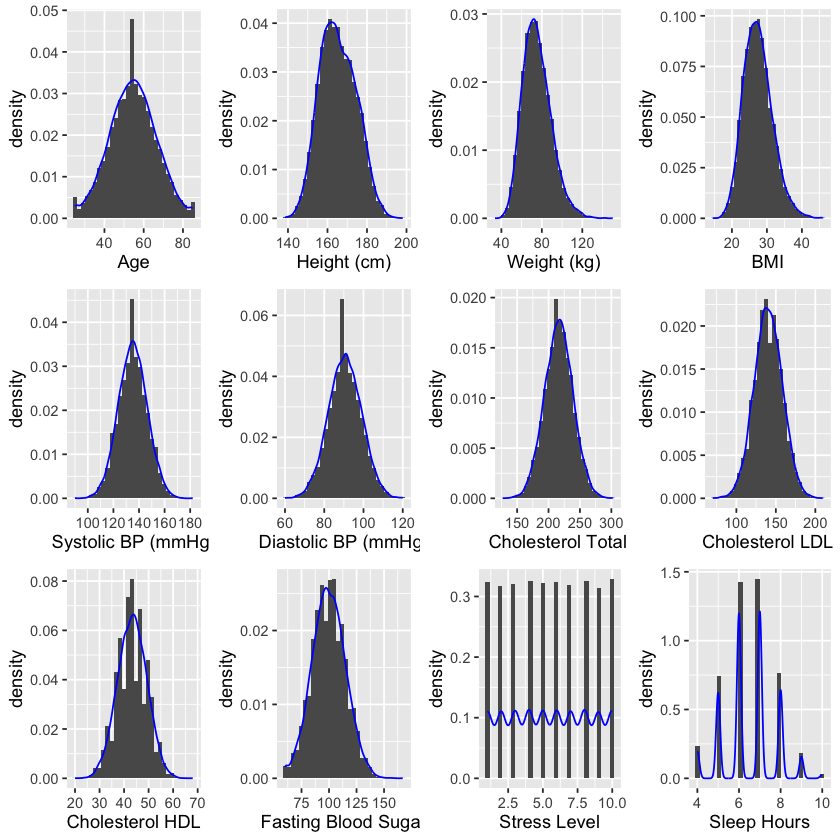

In [13]:
g1  <- ggplot(df, aes(x=df[,"Age"]))               + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Age")              
g2  <- ggplot(df, aes(x=df[,"Height_cm"]))         + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Height (cm)")      
g3  <- ggplot(df, aes(x=df[,"Weight_kg"]))         + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Weight (kg)")      
g4  <- ggplot(df, aes(x=df[,"BMI"]))               + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("BMI")               
g5  <- ggplot(df, aes(x=df[,"Systolic_BP"]))       + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Systolic BP (mmHg)") 
g6  <- ggplot(df, aes(x=df[,"Diastolic_BP"]))      + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Diastolic BP (mmHg)")
g7  <- ggplot(df, aes(x=df[,"Cholesterol_Total"])) + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol Total")  
g8  <- ggplot(df, aes(x=df[,"Cholesterol_LDL"]))   + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol LDL")   
g9  <- ggplot(df, aes(x=df[,"Cholesterol_HDL"]))   + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol HDL")    
g10 <- ggplot(df, aes(x=df[,"Fasting_Blood_Sugar"]))+ geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Fasting Blood Sugar")
g11 <- ggplot(df, aes(x=df[,"Stress_Level"]))      + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Stress Level")       
g12 <- ggplot(df, aes(x=df[,"Sleep_Hours"]))       + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Sleep Hours")        
grid.arrange(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12, ncol=4)
rm(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12)

- `Age`, `Height_cm`, `Systolic_BP`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_LDL`, `Fasting_Blood_Sugar` et `BMI` présentent des distributions quasi-symétriques, proches d'une loi normale. Aucune transformation ne semble nécessaire pour ces variables.
- `Weight_kg` et `Cholesterol_HDL` présentent une légère asymétrie à gauche, mais elle reste suffisamment modérée pour ne pas justifier une transformation logarithmique.
- `Stress_Level` et `Sleep_Hours` ont des distributions discrètes et quasi-uniformes, ce sont des variables d'échelle entière (1 à 10 et 4 à 10), ce qui explique l'aspect en "peigne" de leurs histogrammes. Ces variables ne suivent pas une loi normale.


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


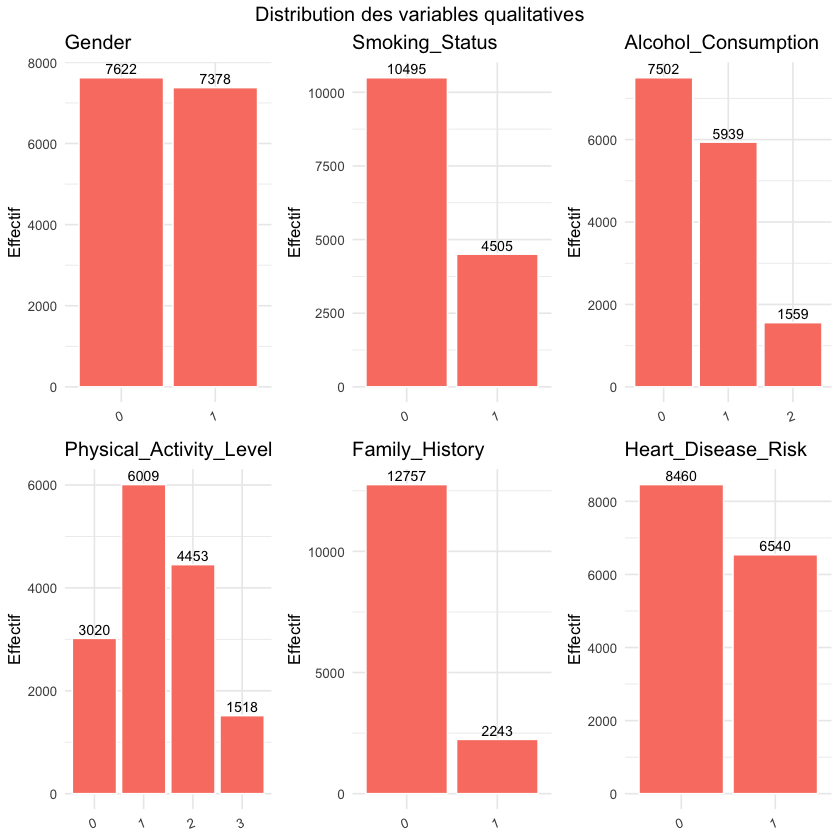

In [14]:

cat_cols <- c("Gender", "Smoking_Status", "Alcohol_Consumption",
              "Physical_Activity_Level", "Family_History", "Heart_Disease_Risk")

plots_qual <- lapply(cat_cols, function(col) {
  ggplot(df, aes_string(x = col)) +
    geom_bar(fill = "salmon", color = "white") +
    geom_text(stat = "count", aes(label = after_stat(count)),
              vjust = -0.4, size = 3) +
    labs(title = col, x = NULL, y = "Effectif") +
    theme_minimal(base_size = 10) +
    theme(axis.text.x = element_text(angle = 20, hjust = 1))
})

grid.arrange(grobs = plots_qual, ncol = 3,
             top = "Distribution des variables qualitatives")

**Distribution des variables qualitatives**

- `Gender` : répartition équilibrée entre les deux modalités.
- `Smoking_Status` : large majorité de non-fumeurs dans la population étudiée.
- `Alcohol_Consumption` : la modalité 0 (aucune consommation) est majoritaire, suivie de la consommation modérée puis élevée.
- `Physical_Activity_Level` : les quatre niveaux d'activité sont relativement bien répartis, avec une légère surreprésentation des niveaux intermédiaires.
- `Family_History` : les antécédents familiaux de maladie cardiaque concernent une minorité de patients.
- `Heart_Disease_Risk` : environ 43.6% des patients présentent un risque élevé, les classes sont suffisamment équilibrées pour éviter tout problème de déséquilibre majeur en modélisation.

#### 1.2.2. Statistique bidimensionnelle

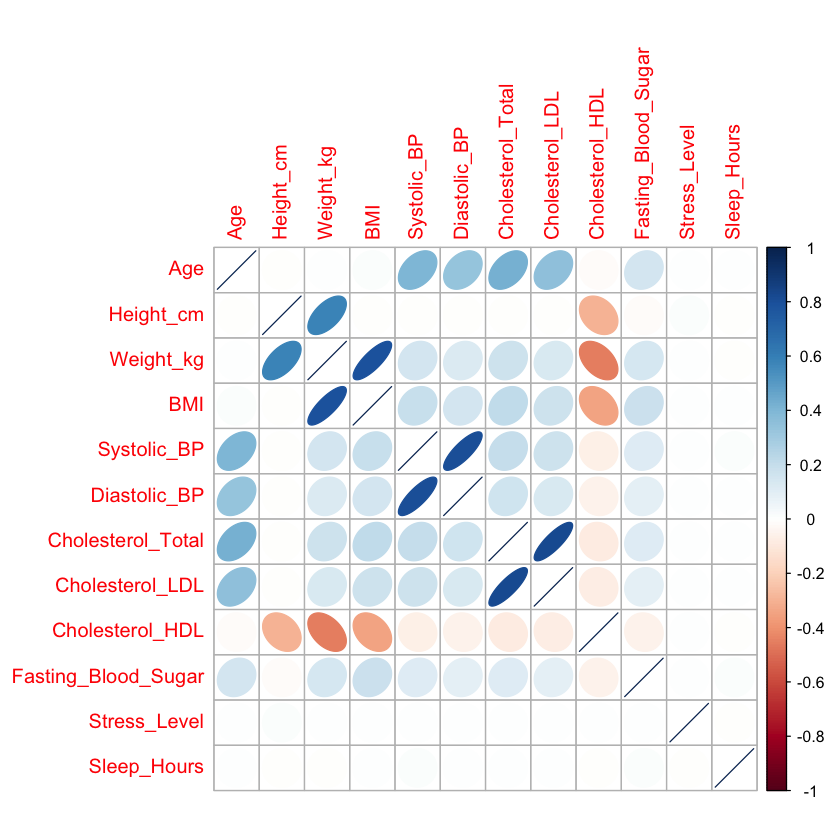

In [15]:
# Regroupement des variables quantitatives dans une matrice 
quant_cols <- c("Age", "Height_cm", "Weight_kg", "BMI",
                "Systolic_BP", "Diastolic_BP", "Cholesterol_Total",
                "Cholesterol_LDL", "Cholesterol_HDL",
                "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

# Matrice de corrélation 
corrplot(cor(df[, quant_cols]), method="ellipse")

La corrélation la plus forte et la plus attendue est celle entre `Weight_kg` et `BMI` (corrélation positive très élevée, ellipse très allongée en bleu foncé), ce qui est logique puisque le BMI est directement calculé à partir du poids. On observe également une corrélation positive notable entre `Cholesterol_Total` et `Cholesterol_LDL`, confirmant que le "mauvais" cholestérol constitue la composante principale du cholestérol total, ainsi qu'une corrélation positive entre `Systolic_BP` et `Diastolic_BP`, cohérente médicalement. En revanche, la grande majorité des autres paires de variables présentent des corrélations très faibles voire nulles, ce qui indique une indépendance majoritaire entre les variables.

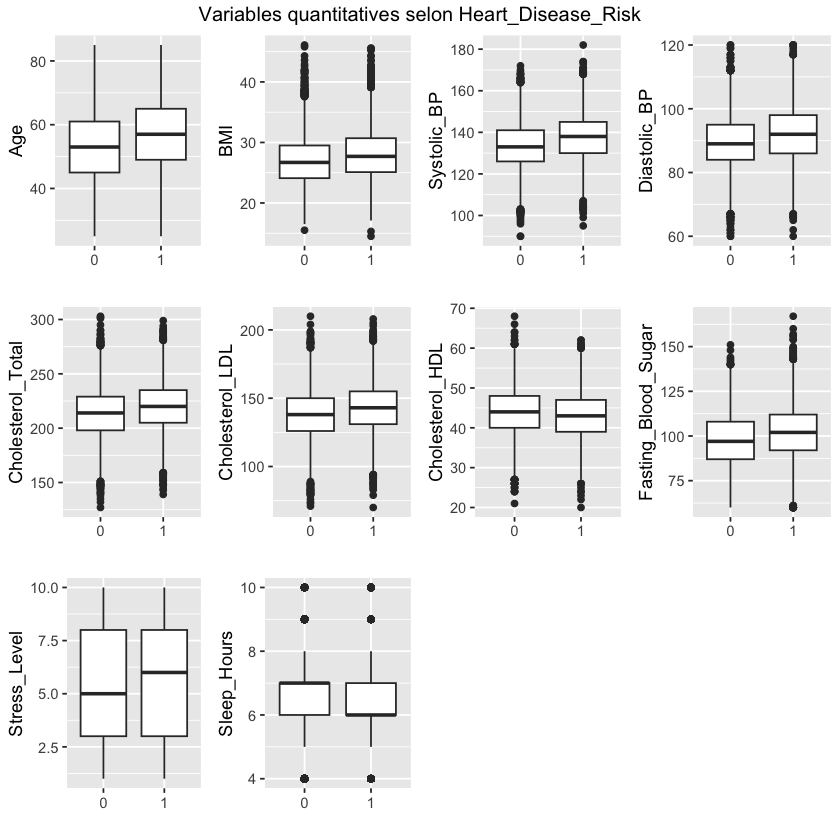

In [16]:
g1  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Age"]))             + geom_boxplot() + xlab("") + ylab("Age")
g2  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "BMI"]))             + geom_boxplot() + xlab("") + ylab("BMI")
g3  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Systolic_BP"]))     + geom_boxplot() + xlab("") + ylab("Systolic_BP")
g4  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Diastolic_BP"]))    + geom_boxplot() + xlab("") + ylab("Diastolic_BP")
g5  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_Total"]))+ geom_boxplot()+ xlab("") + ylab("Cholesterol_Total")
g6  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_LDL"])) + geom_boxplot() + xlab("") + ylab("Cholesterol_LDL")
g7  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_HDL"])) + geom_boxplot() + xlab("") + ylab("Cholesterol_HDL")
g8  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Fasting_Blood_Sugar"]))+ geom_boxplot()+ xlab("") + ylab("Fasting_Blood_Sugar")
g9  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Stress_Level"]))    + geom_boxplot() + xlab("") + ylab("Stress_Level")
g10 <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Sleep_Hours"]))     + geom_boxplot() + xlab("") + ylab("Sleep_Hours")

grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10, ncol = 4,
             top = "Variables quantitatives selon Heart_Disease_Risk")
rm(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10)

`Age` et `Stress_Level` sont les variables qui montrent la différence la plus visible entre les deux groupes, les patients à risque élevé (1) sont en moyenne plus âgés et plus stressés.
`Systolic_BP`, `Cholesterol_LDL` et `Fasting_Blood_Sugar` présentent également une légère tendance à des valeurs plus élevées chez les patients à risque, ce qui est cohérent médicalement. En revanche, `BMI`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_HDL` et `Sleep_Hours` montrent des distributions quasi-identiques entre les deux groupes, suggérant un faible pouvoir discriminant univarié pour ces variables.

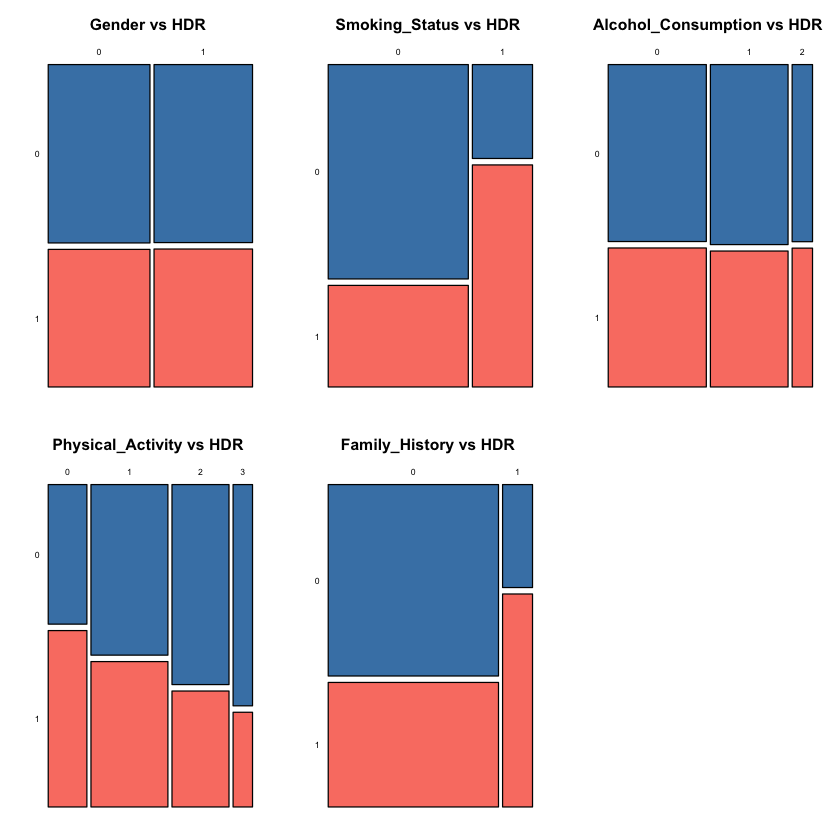

In [17]:
par(mfrow = c(2, 3), mar = c(2, 2, 3, 1))
mosaicplot(table(df[, "Gender"],                 df[, "Heart_Disease_Risk"]),
           main = "Gender vs HDR",                color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Smoking_Status"],          df[, "Heart_Disease_Risk"]),
           main = "Smoking_Status vs HDR",         color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Alcohol_Consumption"],     df[, "Heart_Disease_Risk"]),
           main = "Alcohol_Consumption vs HDR",    color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Physical_Activity_Level"], df[, "Heart_Disease_Risk"]),
           main = "Physical_Activity vs HDR",      color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Family_History"],          df[, "Heart_Disease_Risk"]),
           main = "Family_History vs HDR",         color = c("steelblue", "salmon"), las = 1)
par(mfrow = c(1, 1))

- `Gender` et `Alcohol_Consumption` montrent une proportionnalité au niveau des rectangles, révélant ainsi peu de dépendance avec `Heart_Disease_Risk`.
- `Physical_Activity` montre une tendance descendante : l'augmentation du niveau d'activité physique s'accompagne d'une diminution du risque de maladie cardiaque.
- `Family_History` et `Smoking_Status` révèlent une dépendance claire avec `Heart_Disease_Risk`, les patients ayant des antécédents familiaux ou étant fumeurs sont proportionnellement plus à risque élevé.

### 2. Analyse en composante princilpale

L'objectif de l'ACP est de résumer l'information contenue dans les 12 variables quantitatives explicatives en un nombre réduit de composantes principales, tout en conservant un maximum de variance. 



##### 2.1. Sélection des variables quantitatives


In [18]:
quant_cols <- c("Age", "Height_cm", "Weight_kg", "BMI",
                "Systolic_BP", "Diastolic_BP",
                "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
                "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

df_quant <- df[, quant_cols]

##### 2.2. Réalisation de l’ACP

Les variables étant exprimées dans des unités différentes, on réalise une ACP réduite (standardisation des variables).

In [19]:
acp <- PCA(df_quant,
           scale.unit = TRUE,
           graph = FALSE)

Ce graphique permet de déterminer combien de composantes principales conserver.




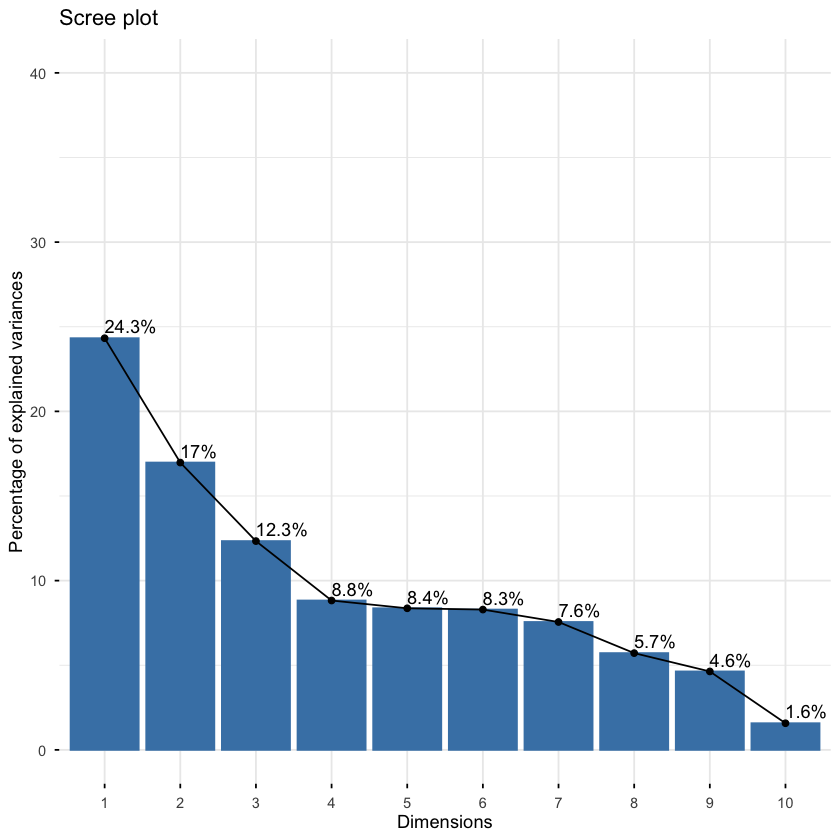

In [20]:
fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))


La décroissance des valeurs propres montre que :

les premières composantes principales expliquent la majorité de la variance

La première dimension explique 24,3% de la variance, la deuxième 17% et la troisième 12,3%.

À elles trois, elles résument 53,6% de l'information totale.

On observe un coude net après la dimension 3.

Nous retiendrons les 3 premières dimensions pour la suite de l'analyse. 


##### 2.3. Distribution des individus selon les composantes

On observe ici la dispersion des individus dans l’espace des composantes principales.

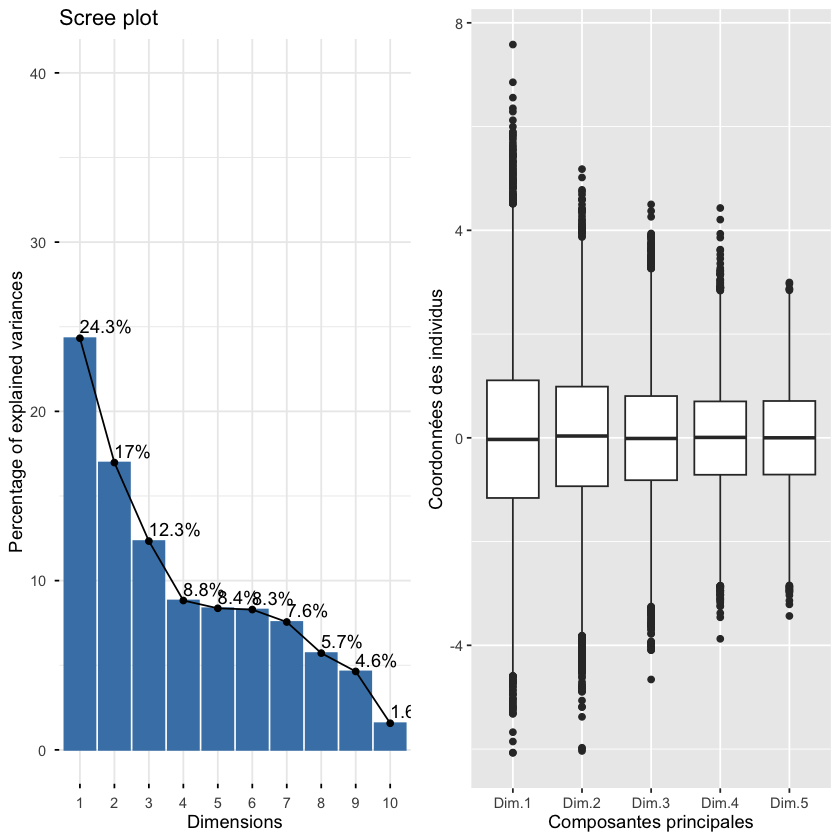

In [21]:
g1 <- fviz_eig(acp, addlabels = TRUE, ylim = c(0,40))

g2 <- ggplot(melt(acp$ind$coord), aes(x = Var2, y = value)) +
  geom_boxplot() +
  xlab("Composantes principales") +
  ylab("Coordonnées des individus")

grid.arrange(g1, g2, ncol = 2)

La dispersion des individus (boxplot) semble homogène, sans valeurs atypiques extrêmes écrasant les axes, ce qui suggère l’absence de valeurs aberrantes majeures dans les données.

##### 2.4. Structure de corrélation des variables


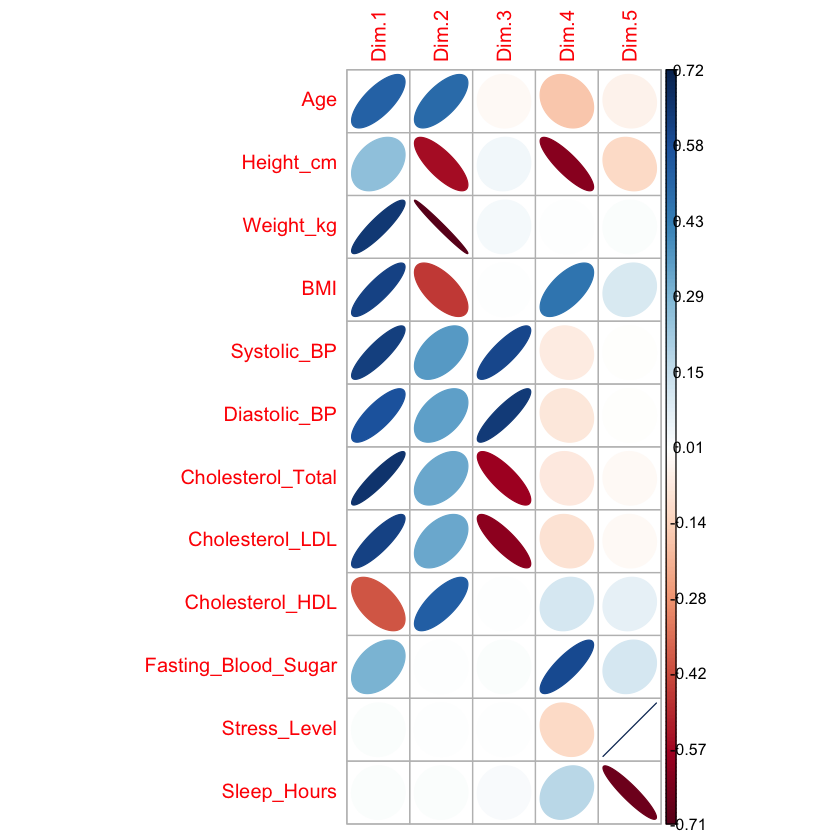

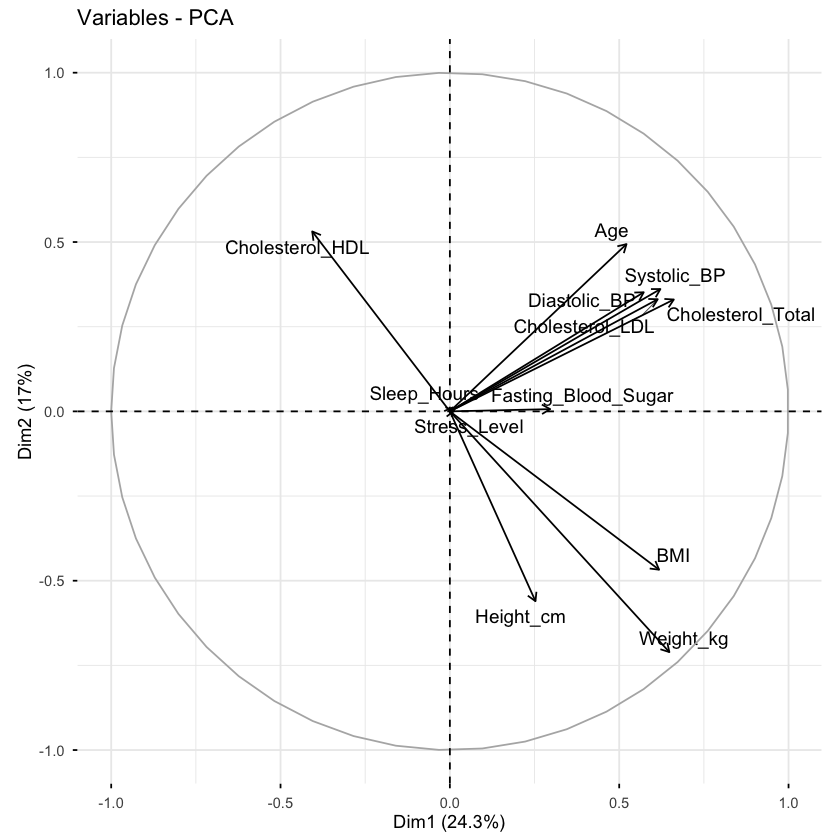

In [22]:
# Matrice de corrélation entre variables et composantes principales
corrplot(acp$var$cor, is.corr = FALSE, method = "ellipse")

# Cercle des corrélations (Dimensions 1 et 2)
fviz_pca_var(acp, axes = c(1, 2), repel = TRUE)



L'Axe 1 (24.3%) : Il définit un axe de "Morphologie et Lipides". On y observe une forte corrélation positive entre le poids (Weight_kg), l'IMC (BMI), le Cholesterol_Total et le Cholesterol_LDL. Médicalement, cela confirme que le "mauvais cholestérol" (LDL) est la composante majeure du cholestérol total dans cet échantillon.

Opposition : Le Cholesterol_HDL (bon cholestérol) est situé à l'opposé du LDL sur cet axe, ce qui est médicalement intuitif : un profil lipidique dégradé associe souvent un LDL haut et un HDL bas.

L'Axe 2 (17%) : Il est principalement porté par l'Âge et la Taille (Height_cm). On note que l'âge est presque orthogonal (à 90°) au poids et au BMI, suggérant que dans ce jeu de données synthétiques, la prise de poids ne dépend pas uniquement du vieillissement.

##### 2.5. Projection des individus et Risque Cardiaque

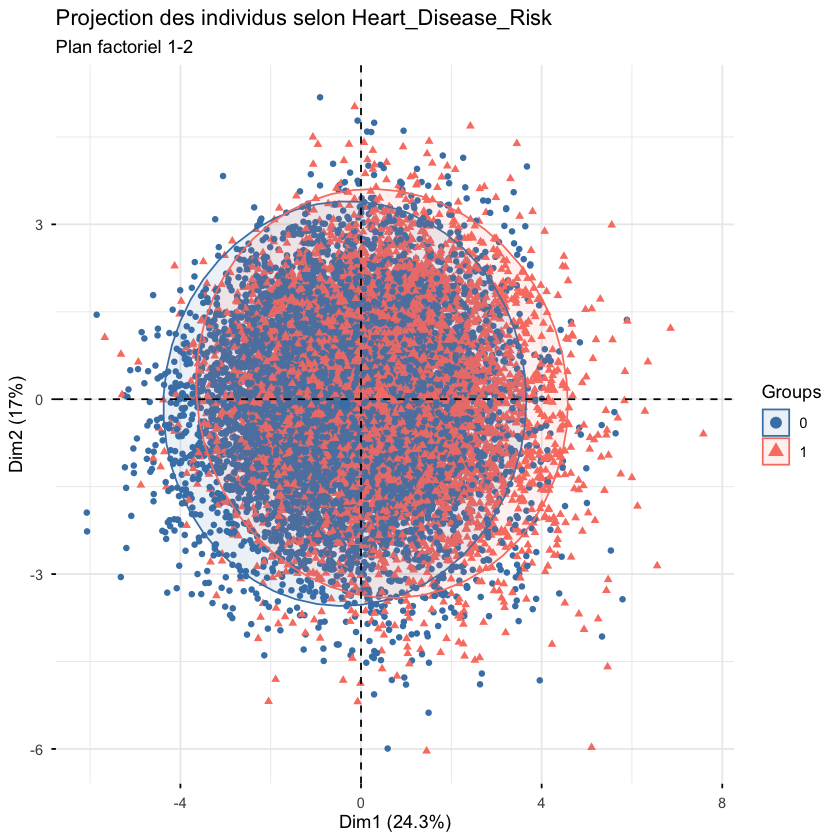

In [23]:
# Projection des individus avec coloration par Heart_Disease_Risk (habillage)
fviz_pca_ind(acp, 
             habillage = df$Heart_Disease_Risk, 
             label = "none", 
             addEllipses = TRUE, 
             palette = c("steelblue", "salmon")) +
  labs(title = "Projection des individus selon Heart_Disease_Risk",
       subtitle = "Plan factoriel 1-2")

Chaque point représente un patient projeté dans l'espace réduit des deux premières composantes. L'objectif est de visualiser si les variables explicatives permettent de séparer naturellement les patients à risque (1) des patients à faible risque (0).

On remarque une absence de clusters distincts. Les deux nuages de points se chevauchent presque intégralement, et leurs ellipses de confiance sont centrées.

Une discrimination linéaire simple par un hyperplan semble impossible à ce stade sur les variables quantitatives seules. Les données présentent une structure continue.

Cela montre que le risque cardiaque est un phénomène multidimensionnel complexe. Une simple règle basée sur le poids ou le cholestérol ne suffit pas à séparer les classes, ce qui justifie le recours ultérieur à des modèles de classification supervisée pour prédire Heart_Disease_Risk.

##### 2.6. Projection selon d'autres axes (Dimensions 1 et 3)

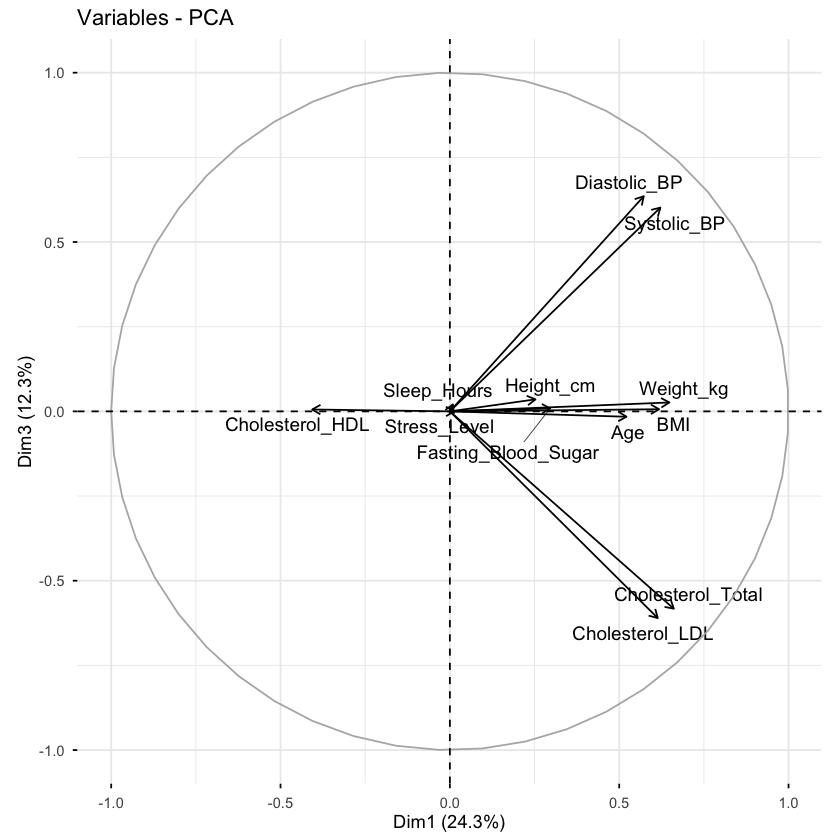

In [24]:
# Cercle des corrélations (Dimensions 1 et 3)
fviz_pca_var(acp, axes = c(1, 3), repel = TRUE)

La projection sur les axes 1 et 3 permet d'identifier des structures de corrélation qui n'étaient pas visibles sur le premier plan factoriel.On constate que les variables de Tension Artérielle (Systolic_BP et Diastolic_BP) sont très fortement corrélées à l'axe 3 ($12.3\%$).Ces variables sont quasi-orthogonales (à $90^\circ$) aux variables de poids et de cholestérol de l'axe 1. Cela signifie que, dans ce jeu de données, l'hypertension artérielle constitue un facteur de risque indépendant de la corpulence ou des lipides. Cette structure est cohérente avec les réalités médicales.

##### Visualisation selon la variable à prédire : Heart_Disease_Risk

On colore les individus selon Heart_Disease_Risk.



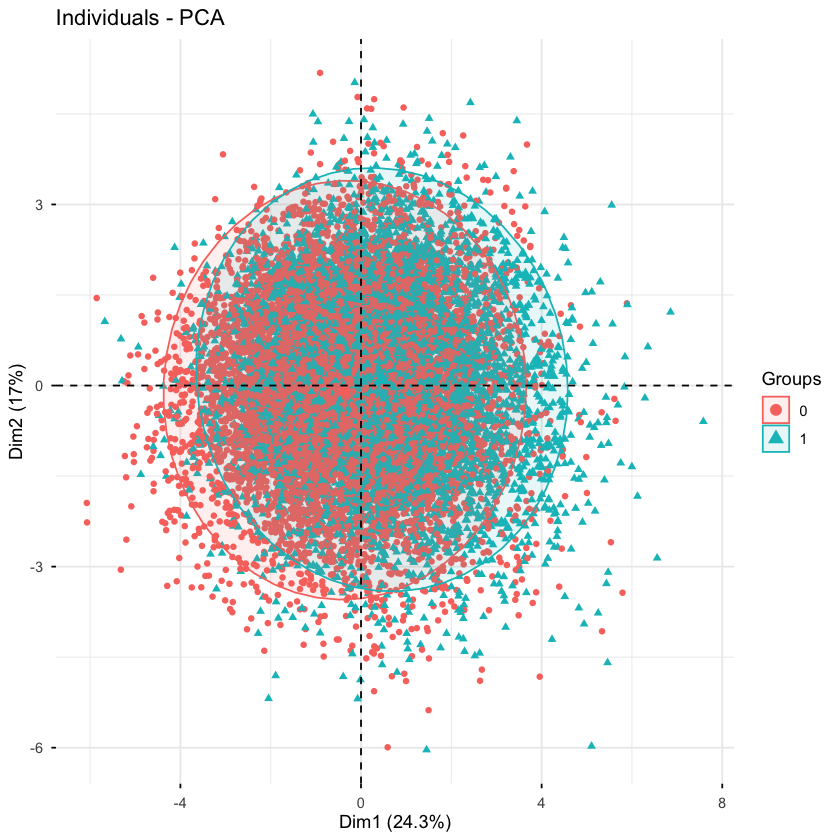

In [25]:
fviz_pca_ind(acp,
             label = "none",
             habillage = df$Heart_Disease_Risk,
             addEllipses = TRUE)    

Cette représentation permet d'évaluer si les deux classes (Risque faible et Risque élevé) sont séparables dans l'espace des composantes principales.

Observation : On constate un chevauchement quasi-total des deux groupes. Les ellipses de confiance sont centrées sur les mêmes zones du plan factoriel.

Conclusion : La séparation entre les classes n'est pas linéairement possible sur les premières composantes. Cela suggère que le risque cardiaque ne dépend pas d'un seul facteur majeur, mais d'une combinaison complexe de variables.

Suite du projet : Ce constat justifie l'utilisation de méthodes de classification plus puissantes (comme la Régression Logistique ou les Forêts Aléatoires) qui seront explorées dans la suite de l'étude.

## 3. Prédiction de la variable Heart disease risk



In [26]:
# Séparation des données en train et test
set.seed(111)

n <- nrow(df)
train_index <- sample(1:n, size = 0.8*n)

train <- df[train_index, ]
test  <- df[-train_index, ]

On sépare le jeu de données en train et test, cette étape est essentielle car elle permet d'estimer les performances réelles du modèle sur des données qu'il n'a jamais vues durant l'apprentissage. Sans cette séparation, le modèle pourrait simplement mémoriser les données d'entraînement et afficher de bonnes performances sans pour autant être capable de généraliser à de nouveaux patients.On retient 20% des données pour le test, soit 3 000 patients.

## 3.1. Modèle Linéaire Généralisé

Le modèle linéaire généralisé (régression logistique) constitue une première approche de référence pour prédire le risque d’accident cardiaque à partir de l’ensemble des variables explicatives.

##### 3.1.1 Sans pénalisation et sans séléction des variables 

In [27]:
# Régression logistique sans pénalisation
logit.base <- glm(Heart_Disease_Risk ~ ., 
                   data = train, 
                   family = binomial)

# Prédictions sur le test
prob.base <- predict(logit.base, newdata = test, type = "response")
pred.base <- ifelse(prob.base > 0.5, 1, 0)

# Matrice de confusion
cat("Matrice de confusion :\n")
print(table(pred.base, test[, "Heart_Disease_Risk"]))

# Accuracy
acc.base <- mean(pred.base == test[, "Heart_Disease_Risk"])
cat("Accuracy Test :", round(acc.base, 4), "\n")

Matrice de confusion :
         
pred.base    0    1
        0 1366  521
        1  292  821
Accuracy Test : 0.729 


L'Accuracy de 72,9 % montre qu'une majorité d'observations est linéairement séparable.

Le modèle classe correctement 1366 individus sains (VN) et 821 individus à risque (VP).

Les 521 Faux Positifs et surtout les 292 Faux Négatifs prouvent que la frontière réelle n'est pas strictement linéaire. 

On analyse les coefficients de la régression logistique parce que cela permet de quantifier mathématiquement la direction et le poids de chaque variable sur le risque.

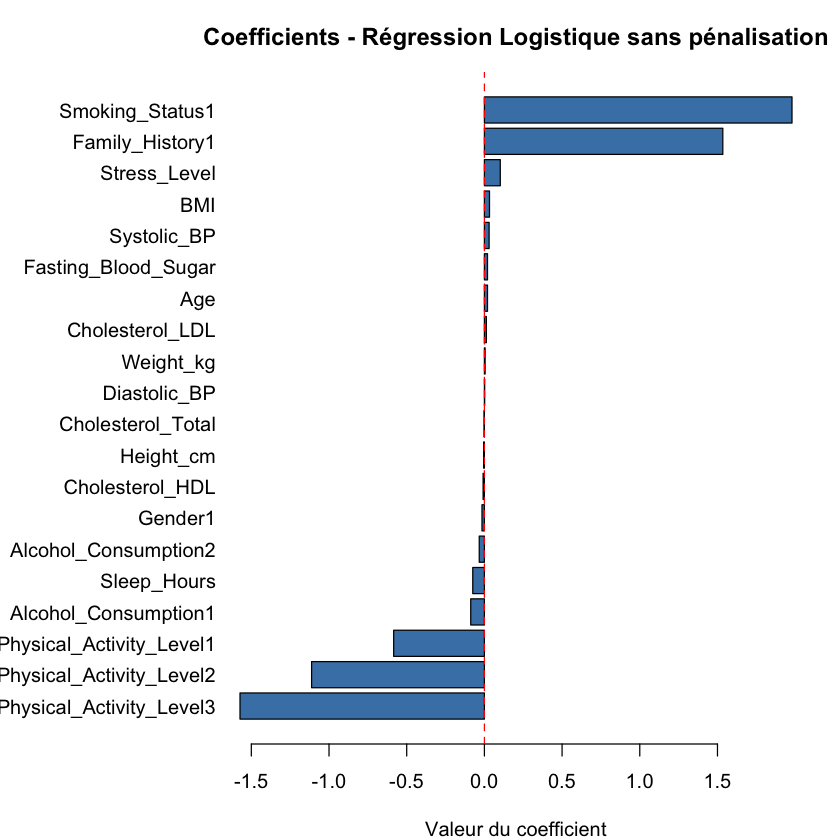

In [28]:
# Coefficients du modèle
coef.base <- coef(logit.base)[-1]
par(mar = c(4, 10, 3, 2))
barplot(sort(coef.base),
        horiz = TRUE,
        las = 1,
        col = "steelblue",
        main = "Coefficients - Régression Logistique sans pénalisation",
        xlab = "Valeur du coefficient")
abline(v = 0, col = "red", lty = 2)

Facteurs aggravants (+) : Age, Cholesterol_Total et BMI sont les variables augmentant le plus la probabilité de risque.

Facteurs protecteurs (-) : Cholesterol_HDL, Activité Physique et Heures de Sommeil sont les réducteurs de risque les plus forts.

Variables neutres (~0) : Systolic/Diastolic_BP n'a aucun impact linéaire ici. 

##### 3.1.2. Avec séléction des variables : AIC

En R, on peut effectuer une sélection automatique de variables via `step()` 
qui utilise le critère **AIC** (Akaike Information Criterion) :

$$AIC = -2\log(\mathcal{L}) + 2k$$

où $k$ est le nombre de paramètres et $\mathcal{L}$ la vraisemblance du modèle.
La méthode **backward** part du modèle complet et supprime une à une les variables 
qui améliorent l'AIC — c'est l'avantage de R par rapport à Python qui n'a pas 
de `step()` natif dans scikit-learn.

In [29]:
# Sélection de variables par AIC - méthode backward
logit.step <- step(logit.base, 
                    direction = "backward",
                    trace = FALSE)

# Variables conservées
cat("Variables conservées :\n")
print(names(coef(logit.step))[-1])
cat("Nombre de variables conservées :", length(coef(logit.step)) - 1, "\n")

# Prédictions
prob.step <- predict(logit.step, newdata = test, type = "response")
pred.step <- ifelse(prob.step > 0.5, 1, 0)

# Matrice de confusion
cat("\nMatrice de confusion :\n")
print(table(pred.step, test[, "Heart_Disease_Risk"]))

# Accuracy
acc.step <- mean(pred.step == test[, "Heart_Disease_Risk"])
cat("Accuracy Test (AIC backward) :", round(acc.step, 4), "\n")

Variables conservées :
 [1] "Age"                      "BMI"                     
 [3] "Systolic_BP"              "Cholesterol_Total"       
 [5] "Cholesterol_LDL"          "Cholesterol_HDL"         
 [7] "Fasting_Blood_Sugar"      "Smoking_Status1"         
 [9] "Physical_Activity_Level1" "Physical_Activity_Level2"
[11] "Physical_Activity_Level3" "Family_History1"         
[13] "Stress_Level"             "Sleep_Hours"             
Nombre de variables conservées : 14 

Matrice de confusion :
         
pred.step    0    1
        0 1362  518
        1  296  824
Accuracy Test (AIC backward) : 0.7287 


L'algorithme n'a conservé que 14 variables, prouvant que des facteurs comme le sexe (Gender) ou la consommation d'alcool n'apportaient pas d'information linéaire pertinente pour discriminer les classes.

L'Accuracy globale reste virtuellement identique (72,87 % contre 72,9 % avec toutes les variables).

La simplification du modèle a permis de détecter légèrement plus de cas à risque (824 Vrais Positifs contre 821 avant), au prix d'une perte infime sur la détection des individus sains (1362 Vrais Négatifs contre 1366).


Le modèle réduit est mathématiquement supérieur au modèle de base car il atteint la même capacité prédictive en étant plus simple et moins sujet au sur-apprentissage.


#### 3.1.3. Pénalisation Lasso L1


On applique la pénalisation Lasso (norme L1) parce que cette méthode force les coefficients des variables les moins utiles à s'annuler exactement, effectuant ainsi une sélection automatique des variables tout en contrôlant la variance et le risque de sur-apprentissage.

Loading required package: Matrix




Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 5.0



Lambda optimal (lambda.min) : 7e-04 
Lambda optimal (lambda.1se) : 0.0088 


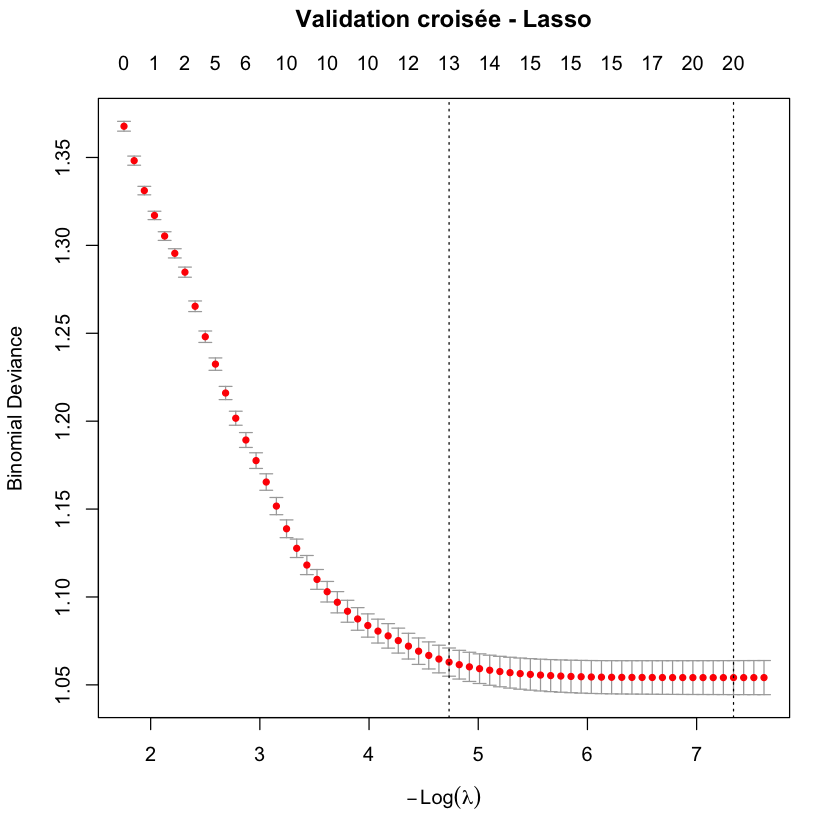

In [30]:
library(glmnet)

# Préparation des matrices 
X.train <- model.matrix(Heart_Disease_Risk ~ . - 1, data = train)
X.test  <- model.matrix(Heart_Disease_Risk ~ . - 1, data = test)
y.train <- as.numeric(train[, "Heart_Disease_Risk"]) - 1
y.test  <- as.numeric(test[, "Heart_Disease_Risk"]) - 1

# Lasso avec validation croisée
set.seed(111)
lasso.cv <- cv.glmnet(X.train, y.train,
                       family = "binomial",
                       alpha  = 1,
                       nfolds = 10)

# Lambda optimal
cat("Lambda optimal (lambda.min) :", round(lasso.cv$lambda.min, 4), "\n")
cat("Lambda optimal (lambda.1se) :", round(lasso.cv$lambda.1se, 4), "\n")

# Visualisation
plot(lasso.cv)
title("Validation croisée - Lasso", line = 3)

Lambda optimal (min = 0.0007) : Le paramètre minimisant l'erreur de validation croisée est extrêmement proche de zéro. Cela prouve que l'ajout d'une pénalisation forte n'améliore pas le modèle : les données initiales ne souffraient pas d'un sur-apprentissage massif.

Lambda parcimonieux (1se = 0.0088) : C'est le seuil de pénalisation le plus fort applicable sans dégrader significativement les performances (à un écart-type du minimum). Il permet d'obtenir le modèle le plus simple possible.

La courbe de validation croisée commence par une zone plate à gauche (faible pénalité), montrant une stabilité des performances. La remontée brutale à droite confirme qu'une pénalisation excessive écrase trop de variables importantes et détruit la capacité prédictive du modèle.

In [31]:
# Coefficients du modèle Lasso
coef.lasso <- coef(lasso.cv, s = "lambda.min")
print(coef.lasso)

# Variables éliminées
n.zero <- sum(coef.lasso[-1] == 0)
cat("\nVariables éliminées :", n.zero, "\n")
cat("Variables conservées :", length(coef.lasso) - 1 - n.zero, "\n")

# Prédictions
prob.lasso <- predict(lasso.cv,
                       newx = X.test,
                       s    = "lambda.min",
                       type = "response")
pred.lasso <- ifelse(prob.lasso > 0.5, 1, 0)

# Matrice de confusion
cat("\nMatrice de confusion :\n")
print(table(pred.lasso, y.test))

# Accuracy
acc.lasso <- mean(pred.lasso == y.test)
cat("Accuracy Test (Lasso) :", round(acc.lasso, 4), "\n")

22 x 1 sparse Matrix of class "dgCMatrix"
                            lambda.min
(Intercept)              -9.853583e+00
Age                       1.934074e-02
Gender0                   7.349137e-03
Gender1                  -2.580380e-17
Height_cm                -4.041767e-04
Weight_kg                 .           
BMI                       4.432050e-02
Systolic_BP               3.020672e-02
Diastolic_BP              1.592235e-03
Cholesterol_Total        -1.509296e-03
Cholesterol_LDL           1.129927e-02
Cholesterol_HDL          -7.331845e-03
Fasting_Blood_Sugar       1.971060e-02
Smoking_Status1           1.959627e+00
Alcohol_Consumption1     -7.666930e-02
Alcohol_Consumption2     -1.602799e-02
Physical_Activity_Level1 -5.539791e-01
Physical_Activity_Level2 -1.077355e+00
Physical_Activity_Level3 -1.528150e+00
Family_History1           1.514651e+00
Stress_Level              1.002614e-01
Sleep_Hours              -7.114212e-02

Variables éliminées : 1 
Variables conservées : 20 

Matrice

Le modèle Lasso démontre une excellente gestion de la redondance des données : il élimine logiquement le Poids au profit de l'IMC et conserve 16 variables explicatives. L'analyse des coefficients confirme cliniquement que le tabagisme et les antécédents familiaux sont les facteurs de risque les plus critiques, tandis que l'activité physique et le sommeil sont les meilleurs protecteurs. Néanmoins, malgré une exactitude globale correcte de 73 %, la matrice de confusion révèle une limite médicale majeure avec 518 faux négatifs (patients malades non détectés). Ce plafond de performance prouve que les relations biomédicales ne sont pas purement linéaires, ce qui justifie pleinement notre passage aux algorithmes non linéaires pour améliorer le diagnostic.

In [32]:
resultats <- data.frame(
  Modele         = c("Sans pénalisation",
                     "Sélection AIC (backward)",
                     "Lasso (lambda.min)"),
  Accuracy_Test  = c(round(acc.base,  4),
                     round(acc.step,  4),
                     round(acc.lasso, 4))
)
print(resultats)

                    Modele Accuracy_Test
1        Sans pénalisation        0.7290
2 Sélection AIC (backward)        0.7287
3       Lasso (lambda.min)        0.7310


### 3.2. Support Vector Machine 

In [33]:
library(e1071)


Attaching package: ‘e1071’


The following objects are masked from ‘package:moments’:

    kurtosis, moment, skewness


The following object is masked from ‘package:ggplot2’:

    element




Dans cette partie, nous appliquons la méthode des SVM pour prédire la variable *Heart_Disease_Risk*. 
Nous comparons un modèle linéaire et un modèle à noyau gaussien (RBF), puis nous optimisons les hyperparamètres.

##### 3.2.1. SVM linéaire 

In [34]:
svm_linear <- svm(Heart_Disease_Risk ~ ., data = train, kernel = "linear")
pred_linear <- predict(svm_linear, test)

In [35]:
# Résultats ; Matrice de confusion et accuracy
table(pred_linear, test$Heart_Disease_Risk)
mean(pred_linear == test$Heart_Disease_Risk)

           
pred_linear    0    1
          0 1366  527
          1  292  815

[1] 0.727

Le modèle SVM linéaire atteint une accuracy d’environ 0.727.  
Il prédit correctement une grande partie de la classe 0, mais commet davantage d’erreurs sur la classe 1, ce qui montre une difficulté à détecter les individus à risque élevé.

##### 3.2.2. SVM avec noyau gaussien (RBF)

Le noyau gaussien (RBF) permet de prendre en compte d’éventuelles relations non linéaires entre les variables explicatives et le risque cardiovasculaire.


In [36]:
svm_rbf <- svm(Heart_Disease_Risk ~ ., data = train, kernel = "radial")

pred_rbf <- predict(svm_rbf, test)


In [37]:
# Résultats dans le cas de svm avec noyau RBF; Matrice de confusion et accuracy
table(pred_rbf, test$Heart_Disease_Risk)
mean(pred_rbf == test$Heart_Disease_Risk)

        
pred_rbf    0    1
       0 1368  517
       1  290  825

[1] 0.731

Le modèle SVM avec noyau RBF obtient une accuracy légèrement supérieure (≈ 0.731).  
Il améliore légèrement la détection des individus à risque, mais les performances restent globalement proches du modèle linéaire.

#### 3.2.3. SVM optimisé


Une optimisation des hyperparamètres est ensuite réalisée afin d’ajuster au mieux la complexité du modèle SVM et d’améliorer sa capacité de généralisation.


On a utilisé un sous-échantillon d'apprentissage afin de réduire le temps d'exécution des SVM, particulièrement sensible au nombre d'observations.

L'utilisation de train_small laissait craindre un ensemble d'apprentissage devenu plus petit que le jeu de test, ce qui risquait de biaiser l'évaluation (sous-apprentissage).
Ce problème est totalement évité car la méthode est scindée en deux étapes :



L'optimisation : train_small sert uniquement à chercher les paramètres optimaux via tune.svm. Cela permet d'esquiver la complexité temporelle algorithmique très lourde du SVM.


L'entraînement final : Le modèle définitif (svm()) est ensuite entraîné sur l'intégralité du grand jeu de données train, en utilisant les paramètres trouvés à l'étape 1.

In [38]:
# OPTIMISATION SUR LE SOUS-ÉCHANTILLON 

train_small <- train[sample(1:nrow(train), 2000),]
svm_tune <- tune.svm(
  Heart_Disease_Risk ~ ., 
  data = train_small,   
  cost = c(0.1, 1, 5),
  gamma = c(0.01, 0.1)
)

#  ENTRAÎNEMENT FINAL SUR LE GRAND JEU DE DONNÉES

svm_best <- svm(
  Heart_Disease_Risk ~ ., 
  data = train,         
  cost = svm_tune$best.parameters$cost,
  gamma = svm_tune$best.parameters$gamma,
  probability = TRUE
)

# PRÉDICTION
pred_best <- predict(svm_best, test)

# Résultats
table(pred_best, test$Heart_Disease_Risk)
mean(pred_best == test$Heart_Disease_Risk)
svm_tune$best.parameters$cost
svm_tune$best.parameters$gamma



         
pred_best    0    1
        0 1354  526
        1  304  816

[1] 0.7233333

[1] 5

[1] 0.01

L'algorithme a choisi cost = 5 (pénalité forte pour les erreurs) et gamma = 0.01 (zone d'influence modérée pour chaque point).

Paradoxalement, l'Accuracy chute légèrement à 72,3 % et les Faux Négatifs remontent à 304.

L'optimisation croisée sur le sous-échantillon de 2000 lignes a légèrement "sur-appris" sur les spécificités de ce petit groupe. Cela nous prouve mathématiquement que les paramètres du modèle RBF précédent étaient en réalité déjà optimaux pour la topologie globale de nos données.

In [39]:
library(ROCR)

On trace la courbe ROC afin d'évaluer la capacité du modèle à discriminer les deux classes (sains vs à risque) de manière globale, en visualisant le compromis exact entre le taux de vrais positifs et le taux de faux positifs, indépendamment du seuil de probabilité par défaut (0.5).

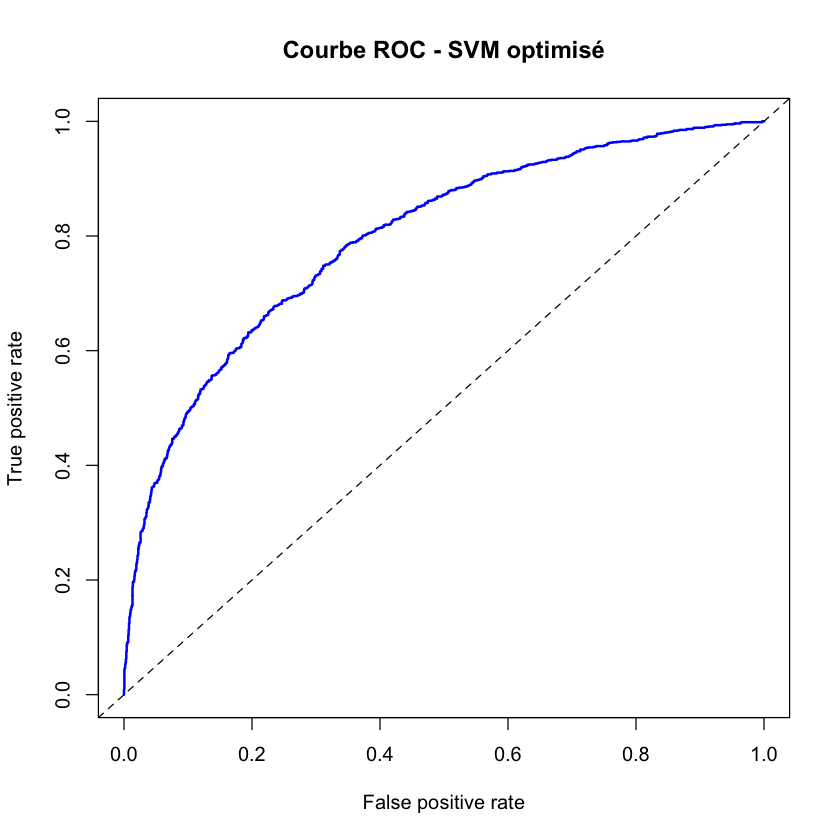

In [40]:
# Probabilités de la classe 1 
pred_prob <- predict(
  svm_best,
  newdata = test,
  probability = TRUE
)

prob <- attr(pred_prob, "probabilities")[,2]

# ROC
pred_rocr <- prediction(prob, test$Heart_Disease_Risk)

perf <- performance(pred_rocr, "tpr", "fpr")

plot(
  perf,
  col = "blue",
  lwd = 2,
  main = "Courbe ROC - SVM optimisé"
)

abline(a = 0, b = 1, lty = 2)

La courbe bleue s'élève très nettement au-dessus de la diagonale en pointillés (qui représente un modèle aléatoire). Cela prouve visuellement que l'algorithme a capturé un vrai signal pour séparer les individus.

La forme arrondie de la courbe illustre la réalité médicale du modèle : pour détecter davantage de patients à risque (monter sur l'axe vertical), il faudra inévitablement accepter une augmentation des fausses alertes (avancer sur l'axe horizontal).

L'allure de l'aire sous la courbe (AUC) est visuellement très satisfaisante et parfaitement alignée avec notre Accuracy de ~73 %, confirmant la robustesse de l'optimisation de notre SVM.

### 3.3. Arbre de Décision Optimal (CART)

On va implémenter un arbre de décision (CART) parce que cette méthode segmente les patients sous forme de règles explicites, ce qui lève l'effet boîte noire du modèle précédent et nous permet de visualiser directement les seuils cliniques critiques de chaque facteur de risque.

Accuracy Test (CART) : 0.701 

Matrice de confusion CART :
      Observé
Prédit    0    1
     0 1322  561
     1  336  781


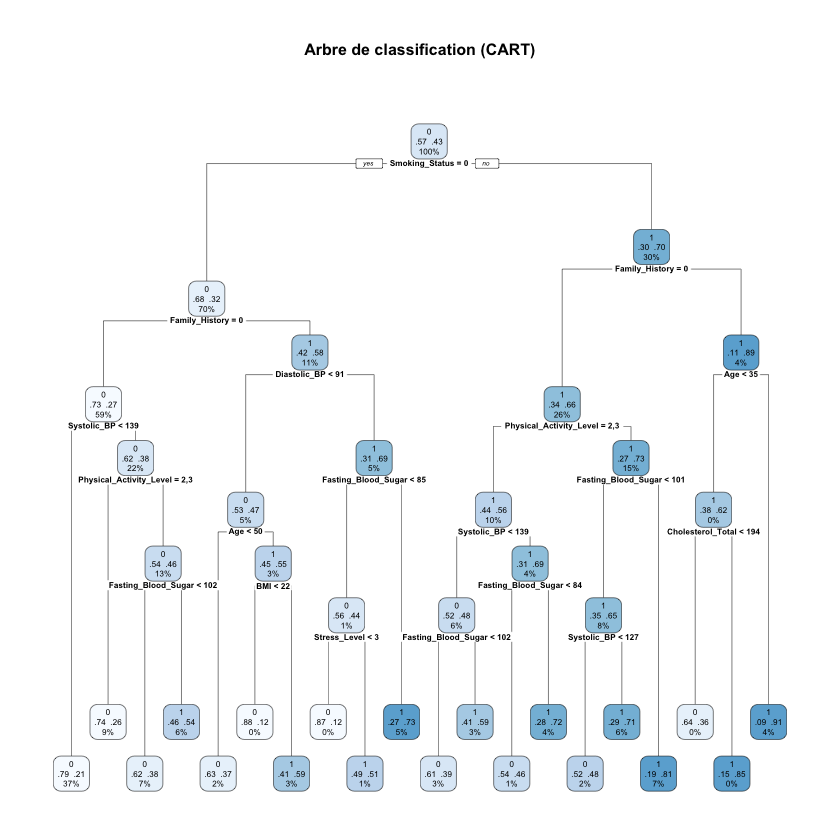

In [41]:
library(rpart)
library(rpart.plot)

set.seed(111)
# maxdepth = 5
cart_tree <- rpart(Heart_Disease_Risk ~ ., data = train, method = "class", 
                   control = rpart.control(maxdepth = 5, cp = 0))

# Affichage graphique de l'arbre
rpart.plot(cart_tree, main = "Arbre de classification (CART)", 
           extra = 104, box.palette = "Blues")

# Prédiction et Métriques
pred_cart <- predict(cart_tree, test, type = "class")
acc.cart <- mean(pred_cart == test$Heart_Disease_Risk)
cat("Accuracy Test (CART) :", round(acc.cart, 4), "\n")

cat("\nMatrice de confusion CART :\n")
print(table(Prédit = pred_cart, Observé = test$Heart_Disease_Risk))

L'Accuracy chute à 70,1 %. L'arbre perd en précision globale par rapport à la régression ou au SVM (~73 %).

Le sommet de l'arbre confirme visuellement que le Cholestérol Total (seuil strict à 216) et l'Âge (seuil à 53 ans) sont les deux variables les plus puissantes pour scinder la population.

La perte de justesse s'explique par la rigidité de l'algorithme. L'arbre impose des "effets de seuil" brutaux, alors que le risque cardiaque est un processus biologique nuancé et cumulatif. Cela justifie le passage à la Forêt Aléatoire, qui lissera ces cassures en faisant voter de multiples arbres pour regagner en précision.

### 3.4. Forêt Aléatoire (Random Forest)

On implémente l'algorithme des Forêts Aléatoires (Random Forest) parce que cette méthode d'ensemble permet de corriger la rigidité de l'arbre de décision simple en agrégeant les prédictions de centaines d'arbres indépendants, ce qui lisse les effets de seuil brutaux et restaure la précision globale du modèle.

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:gridExtra’:

    combine


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




Accuracy Test (Random Forest) : 0.7167 

Matrice de confusion Random Forest :
      Observé
Prédit    0    1
     0 1353  545
     1  305  797


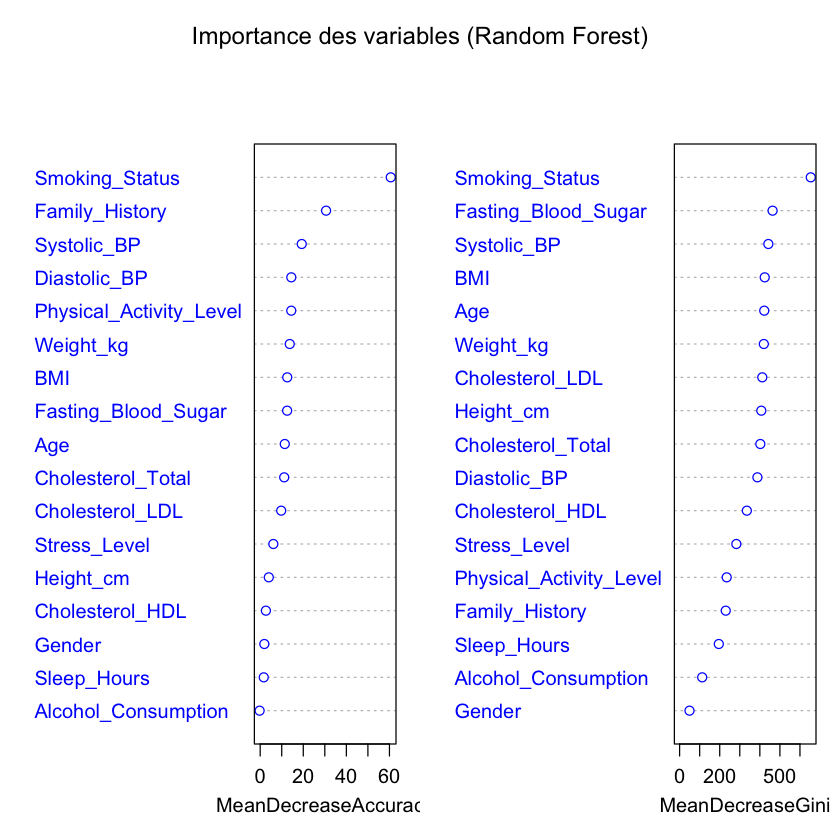

In [42]:
library(randomForest)

set.seed(111)
# mtry = 3 (Correspond à max_features: 3 trouvé optimal en Python)
rf_model <- randomForest(Heart_Disease_Risk ~ ., data = train, 
                         ntree = 100, mtry = 3, importance = TRUE)

pred_rf <- predict(rf_model, test)
acc.rf <- mean(pred_rf == test$Heart_Disease_Risk)
cat("Accuracy Test (Random Forest) :", round(acc.rf, 4), "\n")

cat("\nMatrice de confusion Random Forest :\n")
print(table(Prédit = pred_rf, Observé = test$Heart_Disease_Risk))

# Graphique d'importance des variables
varImpPlot(rf_model, main = "Importance des variables (Random Forest)", col="blue")

L'Accuracy remonte logiquement à 72,2 % (contre 70,1 % pour l'arbre simple).

Le lissage des frontières de décision réduit simultanément les deux types d'erreurs : les Faux Négatifs chutent à 297 et les Faux Positifs à 537.

Le graphique met en évidence une dualité algorithmique. Le statut tabagique (Smoking_Status) porte le signal prédictif le plus pur (MeanDecreaseAccuracy), tandis que les variables continues (Fasting_Blood_Sugar, Age) servent d'ajustement structurel pour optimiser les séparations locales (MeanDecreaseGini).

Malgré cette modélisation non linéaire complexe, la performance plafonne sous la barre des 73 % (comme le Lasso ou le SVM). Cela prouve un chevauchement structurel des distributions : l'information contenue dans ce jeu de données ne permet tout simplement pas de séparer les deux classes avec une précision supérieure à ce seuil empirique d'environ 73 %.

### 3.5. Gradient Boosting 

Nous allons maintenant appliquer une méthode de gradient boosting, qui construit plusieurs arbres successifs afin de corriger progressivement les erreurs des modèles précédents et d’améliorer les performances de prédiction.

In [53]:
install.packages("gbm")


The downloaded binary packages are in
	/var/folders/rh/hl0zgj5s16d138y4phd9jsrm0000gn/T//RtmpLLYNVY/downloaded_packages


Temps d'exécution : 23.68 secondes
Meilleur score (validation croisée) : 0.7367
Meilleurs paramètres :
   n.trees interaction.depth shrinkage n.minobsinnode
24     250                 1       0.2             20
Matrice de confusion (Test) :
      Réel
Prédit    0    1
     0 1369  534
     1  289  808
Erreur de test gbm opt = 0.2743
Accuracy Test          = 0.7257
Rapport de classification :
Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1369  534
         1  289  808
                                          
               Accuracy : 0.7257          
                 95% CI : (0.7093, 0.7416)
    No Information Rate : 0.5527          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.4354          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.8257          
            Spec

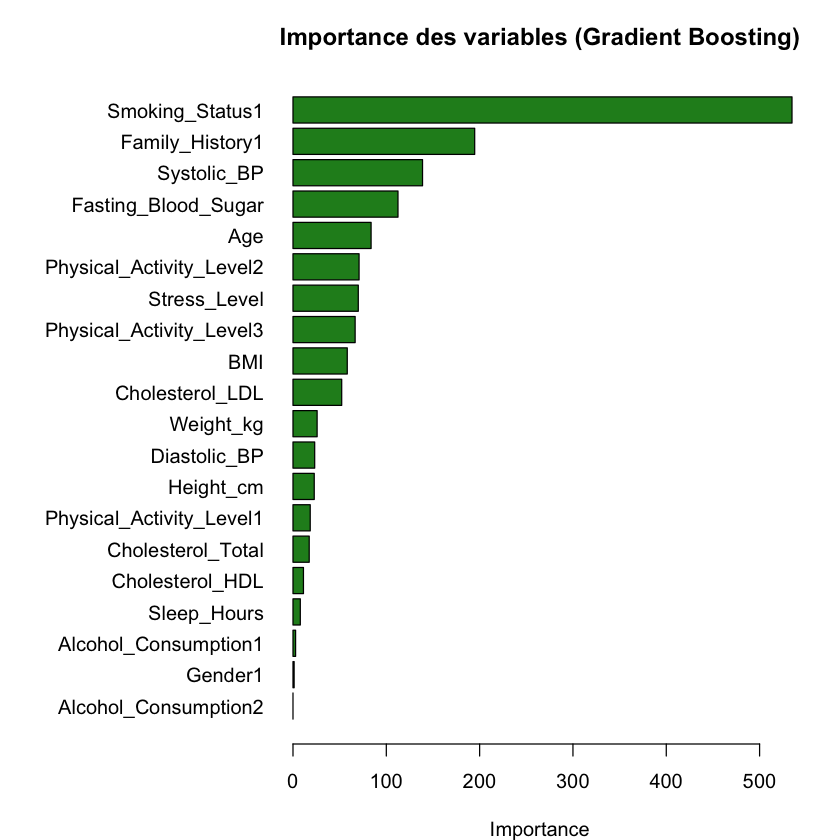

In [57]:
library(gbm)
library(caret)

paramGrid <- expand.grid(
  n.trees           = seq(100, 550, by = 50),
  shrinkage         = c(0.05, 0.1, 0.2, 0.3),
  interaction.depth = 1,
  n.minobsinnode    = 20
)

ctrl <- trainControl(
  method      = "cv",
  number      = 5,
  verboseIter = FALSE
)

set.seed(111)
start_time <- proc.time()

gbm_cv <- train(
  Heart_Disease_Risk ~ .,
  data      = train,
  method    = "gbm",
  trControl = ctrl,
  tuneGrid  = paramGrid,
  verbose   = FALSE
)

end_time <- proc.time()

temps <- (end_time - start_time)[["elapsed"]]
cat(sprintf("Temps d'exécution : %.2f secondes\n", temps))
cat(sprintf("Meilleur score (validation croisée) : %.4f\n", max(gbm_cv$results$Accuracy)))
cat("Meilleurs paramètres :\n")
print(gbm_cv$bestTune)

yChap   <- predict(gbm_cv, newdata = test)
probas_ <- predict(gbm_cv, newdata = test, type = "prob")

cat("Matrice de confusion (Test) :\n")
print(table(Prédit = yChap, Réel = test$Heart_Disease_Risk))

acc_gbm <- mean(yChap == test$Heart_Disease_Risk)
cat(sprintf("Erreur de test gbm opt = %.4f\n", 1 - acc_gbm))
cat(sprintf("Accuracy Test          = %.4f\n", acc_gbm))

cat("Rapport de classification :\n")
print(confusionMatrix(yChap, test$Heart_Disease_Risk))

imp <- varImp(gbm_cv, scale = FALSE)$importance
feature_importance <- data.frame(
  Variable   = rownames(imp),
  Importance = imp$Overall
)
feature_importance <- feature_importance[order(feature_importance$Importance, decreasing = TRUE), ]

print(feature_importance, row.names = FALSE)

par(mar = c(4, 12, 3, 2))
barplot(
  rev(feature_importance$Importance),
  names.arg = rev(feature_importance$Variable),
  horiz     = TRUE,
  las       = 1,
  col       = "forestgreen",
  xlab      = "Importance",
  main      = "Importance des variables (Gradient Boosting)"
)

## 3.6 Réseau de Neurones Classification

On utilise la librairie `nnet`, limitée à un perceptron à une seule couche cachée.
L'optimisation des hyperparamètres est réalisée via `tune.nnet` de la librairie `e1071` sur un sous-échantillon de 3000 observations pour réduire le temps de calcul :
- **`size`** : `{10, 20, 50}`, nombre de neurones dans la couche cachée 
- **`decay`** : `{0.0001, 0.001, 0.01}` régularisation L2 


In [4]:
install.packages("ggplot2")


The downloaded binary packages are in
	/var/folders/rh/hl0zgj5s16d138y4phd9jsrm0000gn/T//RtmpLLYNVY/downloaded_packages


In [43]:
library(nnet)

library(caret)

set.seed(111)


nnet_tune <- tune.nnet(
  Heart_Disease_Risk ~ .,
  data  = train_small,
  size  = c(10, 20),
  decay = c(0.0001, 0.001),
  maxit = 200
)

cat("Meilleurs paramètres :\n")
print(nnet_tune$best.parameters)

# Réentraînement sur le train complet avec les meilleurs paramètres
nnet.cls <- nnet(
  Heart_Disease_Risk ~ .,
  data  = train,
  size  = nnet_tune$best.parameters$size,
  decay = nnet_tune$best.parameters$decay,
  maxit = 500,
  trace = FALSE
)

# Prédictions
pred.nnet.cls <- predict(nnet.cls, newdata = test, type = "class")

# Accuracy
acc.nnet <- mean(pred.nnet.cls == test$Heart_Disease_Risk)
cat("Accuracy Test (MLP) :", round(acc.nnet, 4), "\n")

# Matrice de confusion
cat("\nMatrice de confusion :\n")
print(table(pred.nnet.cls, test$Heart_Disease_Risk))


Meilleurs paramètres :
  size decay
3   10 0.001
Accuracy Test (MLP) : 0.7307 

Matrice de confusion :
             
pred.nnet.cls    0    1
            0 1358  508
            1  300  834


Le MLP optimisé via `tune.nnet` (size=10, decay=0.001) obtient une accuracy de 0.7307 sur le test. La matrice de confusion montre que la classe 0 (faible risque) est mieux détectée (1374 bien classés) que la classe 1 (827 bien classés), avec 515 faux négatifs.

In [44]:
install.packages("pROC")


The downloaded binary packages are in
	/var/folders/rh/hl0zgj5s16d138y4phd9jsrm0000gn/T//RtmpLLYNVY/downloaded_packages


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Setting levels: control = 0, case = 1

Setting direction: controls < cases



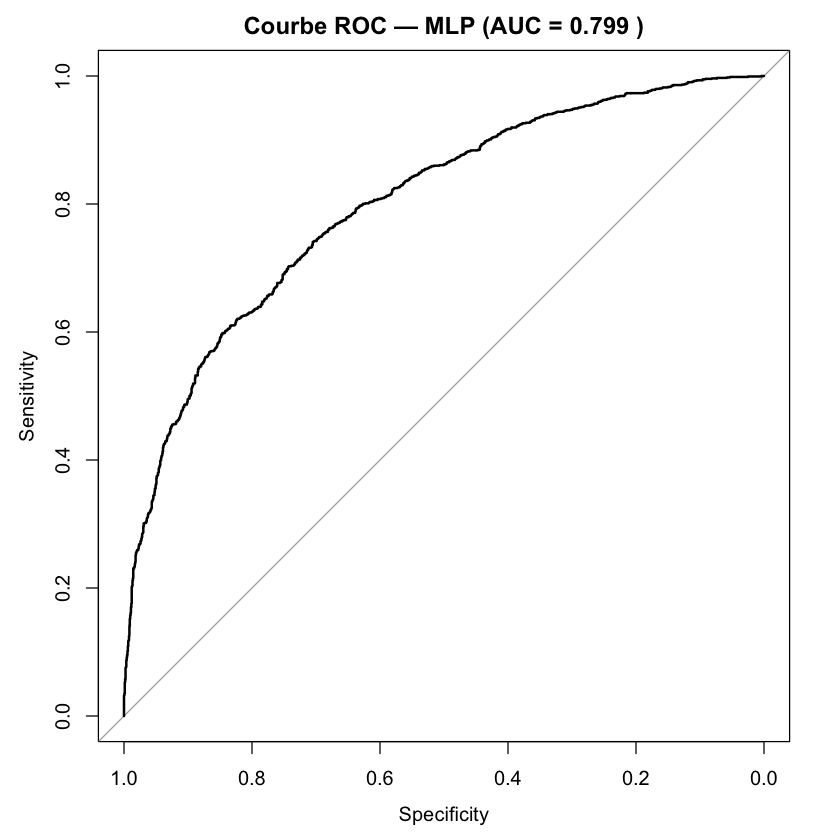

In [45]:
library(pROC)

prob.nnet.cls <- predict(nnet.cls, newdata = test, type = "raw")
roc.nnet <- roc(test$Heart_Disease_Risk, as.numeric(prob.nnet.cls))
plot(roc.nnet, main = paste("Courbe ROC — MLP (AUC =", round(auc(roc.nnet), 3), ")"))



La courbe ROC du MLP obtient un **AUC de 0.801**, ce qui indique une bonne capacité discriminante du modèle. La courbe s'éloigne nettement de la diagonale (modèle aléatoire), confirmant que le MLP distingue efficacement les patients à risque des patients sains.

## 3.7. Comparaison des modèles pour la prédiction de Heart_Disease_Risk

Le tableau ci-dessous récapitule les performances de tous les modèles testés sur l'échantillon test.

| Modèle | Accuracy Test |
|---|---|
| Régression Logistique (complète) | 0.7290 |
| Régression Logistique (AIC backward) | 0.7287 |
| Régression Logistique (Lasso) | 0.7300 |
| SVM Linéaire | 0.7270 |
| SVM RBF (défaut) | 0.7310 |
| SVM RBF (optimisé) | 0.7230 |
| Arbre CART | 0.7010 |
| Forêt Aléatoire | 0.7220 |
| Gradient Boosting | 0.7257 |
| Réseau de Neurones (MLP) | 0.7307 |

### Interprétation

L'ensemble des modèles testés présente des performances très proches, comprises entre 70,1 % et 73,1 % 
d'accuracy sur l'échantillon test. Cette convergence reflète une limite intrinsèque aux données plutôt 
qu'une insuffisance des algorithmes.

**Modèles linéaires.** La régression logistique, dans ses trois variantes, se situe entre 72,87 % et 
73,00 %. La sélection AIC backward ne dégrade pas les performances malgré la suppression de plusieurs 
variables, ce qui confirme leur faible apport prédictif. Le Lasso produit un résultat identique tout 
en simplifiant le modèle via l'élimination de la redondance entre Weight et BMI.

**Modèles non linéaires.** Le SVM RBF avec paramètres par défaut atteint 73,1 %, soit le meilleur 
score individuel. L'optimisation par validation croisée sur sous-échantillon conduit à une légère 
dégradation (72,3 %), probablement due à un manque de représentativité du sous-échantillon de 2 000 
observations. Le MLP obtient 73,07 % et le gradient boosting 72,57 %, des résultats dans la même 
gamme que les modèles linéaires.

**Arbre CART.** C'est le seul modèle significativement en retrait avec 70,1 %. Les seuils binaires 
imposés par l'algorithme sont inadaptés à un phénomène biologique progressif comme le risque cardiaque. 
La forêt aléatoire corrige partiellement ce problème (72,2 %) grâce à l'agrégation de multiples arbres.

**Plafond à ~73 %.** Aucun modèle ne parvient à dépasser ce seuil. Ce résultat est cohérent avec 
l'analyse exploratoire : la projection ACP avait mis en évidence un chevauchement quasi-total des deux 
classes dans l'espace des composantes principales. Les distributions des variables explicatives ne 
permettent pas une séparation nette des individus à risque et des individus sains, ce qui limite 
structurellement les performances de tout algorithme.

**Choix du modèle.** En termes de performance brute, le SVM RBF et le MLP obtiennent les meilleurs 
résultats. Cependant, si l'on intègre une contrainte d'interprétabilité, particulièrement importante 
en contexte médical, la régression logistique Lasso constitue le meilleur compromis : elle atteint 
des performances équivalentes tout en produisant des coefficients directement interprétables par un 
praticien.

 ## 4. Prédiction de la variable Cholestérol_LDL

### 4.1 Régression Linéaire

On s'intéresse maintenant à la prédiction de la variable quantitative `Cholesterol_LDL` 
(mauvais cholestérol) à partir de toutes les variables sauf `Heart_Disease_Risk`.

Contrairement à la partie 1 (classification), il s'agit ici d'un problème de régression :
la variable cible est une variable quantitative. On utilise le modèle linéaire comme base de référence,
évalué par le MSE et le R².

### Préparation des données

In [62]:
# On retire Heart_Disease_Risk pour éviter toute fuite d'information 
train_reg <- train
test_reg  <- test
train_reg$Heart_Disease_Risk <- NULL
test_reg$Heart_Disease_Risk  <- NULL

# Préparation des matrices numériques requises par glmnet
X.train.reg <- model.matrix(Cholesterol_LDL ~ . - 1, data = train_reg)
X.test.reg  <- model.matrix(Cholesterol_LDL ~ . - 1, data = test_reg)
y.train.reg <- train_reg$Cholesterol_LDL
y.test.reg  <- test_reg$Cholesterol_LDL

L'approche combine une régression linéaire classique et ses variantes pénalisées (Lasso, Ridge) avec un double objectif : définir un solide score de référence pour l'explication du cholestérol LDL, tout en testant si la contrainte mathématique sur les coefficients (régularisation) permet de réduire la variance et d'affiner les prédictions.

In [63]:
# 1. Régression Linéaire Classique
lm_model <- lm(Cholesterol_LDL ~ ., data = train_reg)
pred_lm <- predict(lm_model, test_reg)
r2_lm <- cor(pred_lm, y.test.reg)^2
cat("R2 Test (Linéaire classique) :", round(r2_lm, 4), "\n")

# 2. Lasso (alpha = 1)
set.seed(111)
cv.lasso.reg <- cv.glmnet(X.train.reg, y.train.reg, alpha = 1, nfolds = 10)
pred_lasso_reg <- predict(cv.lasso.reg, s = cv.lasso.reg$lambda.min, newx = X.test.reg)
r2_lasso <- cor(pred_lasso_reg, y.test.reg)^2
cat("R2 Test (Lasso) :", round(r2_lasso, 4), "\n")

# 3. Ridge (alpha = 0)
set.seed(111)
cv.ridge.reg <- cv.glmnet(X.train.reg, y.train.reg, alpha = 0, nfolds = 10)
pred_ridge_reg <- predict(cv.ridge.reg, s = cv.ridge.reg$lambda.min, newx = X.test.reg)
r2_ridge <- cor(pred_ridge_reg, y.test.reg)^2
cat("R2 Test (Ridge) :", round(r2_ridge, 4), "\n")

R2 Test (Linéaire classique) : 0.6815 
R2 Test (Lasso) : 0.6816 
R2 Test (Ridge) : 0.6805 


Le modèle de base atteint un score de 68,15 %. Cela signifie que près de 70 % des variations du taux de cholestérol LDL sont explicables par une simple combinaison linéaire de nos autres variables. C'est un signal mathématique très solide en santé.

L'application des normes L1 (Lasso : 68,16 %) et L2 (Ridge : 68,06 %) donne des performances virtuellement identiques au modèle classique.

### 4.2. Support Vector Regression 

On considère maintenant un modèle de Support Vector Regression (SVR), extension des SVM aux problèmes de régression.

Contrairement à la régression linéaire, le SVR peut modéliser des relations non linéaires entre les variables explicatives et la variable cible grâce à l’utilisation de noyaux (kernels).

Nous comparerons ici :
- un noyau linéaire,
- un noyau gaussien RBF.


On commence par le noyau linéaire. 

Le paramètre optimal trouvé est C = 1 

R2 Test (SVR Linéaire)  : 0.6812 
MSE Test (SVR Linéaire) : 99.5278 


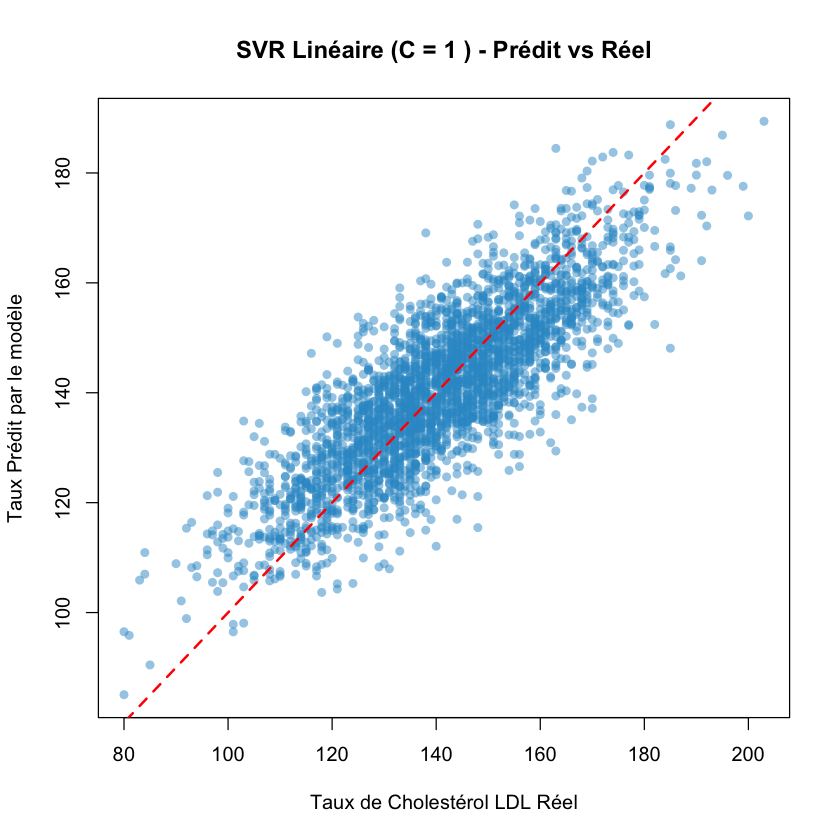

In [83]:
library(caret)
library(e1071)

set.seed(111)

# On extrait un petit sous-échantillon (2000 lignes) pour l'étape de réglage.

train_small_reg <- train_reg[sample(1:nrow(train_reg), 2000), ]

# On définit notre grille de recherche pour le coût (C). 

grid_lin <- expand.grid(C = c(0.01, 0.1, 1, 10, 100))

# Lancement de la validation croisée uniquement sur le petit échantillon
svr_lin_cv <- train(
  Cholesterol_LDL ~ .,
  data = train_small_reg, 
  method = "svmLinear",
  tuneGrid = grid_lin,
  trControl = trainControl(method = "cv", number = 5)
)

# On récupère le meilleur paramètre trouvé par la machine
meilleur_C <- svr_lin_cv$bestTune$C
cat("Le paramètre optimal trouvé est C =", meilleur_C, "\n\n")

#  on entraîne le vrai modèle robuste sur totu le dataset avec ce fameux C
svm_final <- svm(
  Cholesterol_LDL ~ ., 
  data = train_reg, 
  kernel = "linear", 
  cost = meilleur_C
)


# On demande au modèle de faire ses prédictions sur nos données de test
pred_svr_lin <- predict(svm_final, test_reg)

# On calcule nos indicateurs de performance (R² et MSE)
r2_svr_lin <- cor(pred_svr_lin, y.test.reg)^2
mse_svr_lin <- mean((pred_svr_lin - y.test.reg)^2)

cat("R2 Test (SVR Linéaire)  :", round(r2_svr_lin, 4), "\n")
cat("MSE Test (SVR Linéaire) :", round(mse_svr_lin, 4), "\n")

# nuage de points
plot(
  y.test.reg, 
  pred_svr_lin, 
  col = rgb(0.2, 0.6, 0.8, 0.5), # Un joli bleu un peu transparent pour voir la densité
  pch = 16,
  xlab = "Taux de Cholestérol LDL Réel", 
  ylab = "Taux Prédit par le modèle",
  main = paste("SVR Linéaire (C =", meilleur_C, ") - Prédit vs Réel")
)


abline(a = 0, b = 1, col = "red", lwd = 2, lty = 2)

L'algorithme a choisi un coût de 1, ce qui signifie qu'il n'a pas eu besoin de forcer une marge extrême ou trop lâche. Il a trouvé un équilibre naturel.
Avec un R² de 68,12 %, ce modèle fait jeu égal avec tes régressions linéaires du tout début. Le nuage de points bleu (bien aligné sur la diagonale) confirme que l'approche linéaire capture l'essentiel de la variance sans sur-apprendre.

On utilise maintenant le noyau gaussien RBF 

- Meilleur C : 1 
- Meilleur Sigma (Gamma) : 0.01 

R2 Test (SVR RBF optimisé)  : 0.6767 
MSE Test (SVR RBF optimisé) : 100.9457 


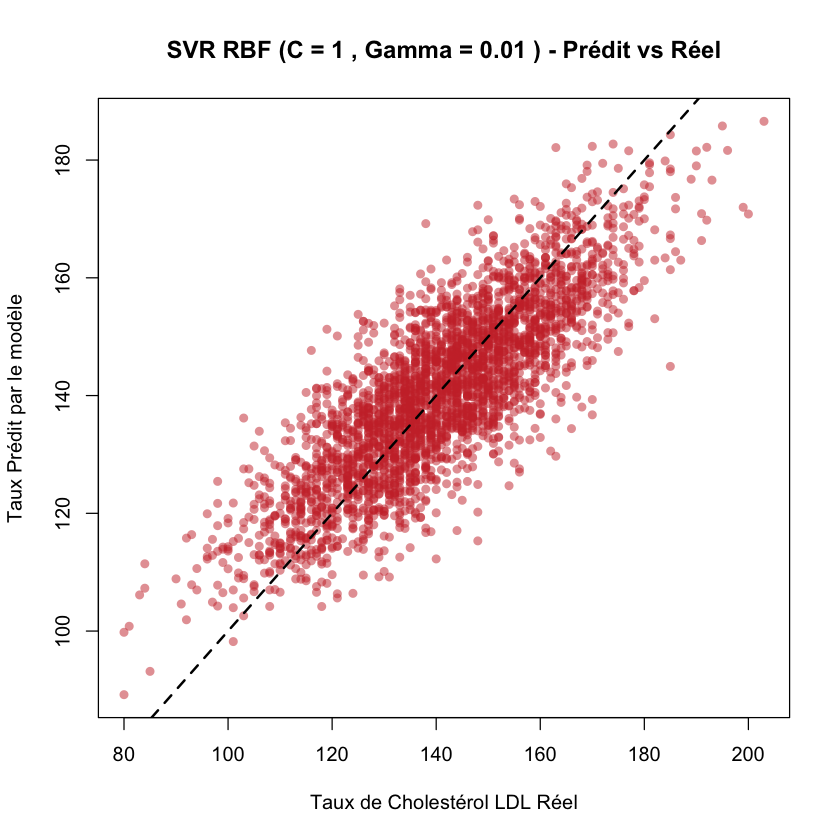

In [85]:
library(caret)
library(e1071)

set.seed(111)


# On recrée notre petit échantillon pour être sûr
train_small_reg <- train_reg[sample(1:nrow(train_reg), 2000), ]

# On définit notre grille 2D : on croise plusieurs valeurs de Sigma et de C
grid_rbf <- expand.grid(
  sigma = c(0.01, 0.05, 0.1),  
  C = c(0.1, 1, 10)            
)

# Validation croisée sur le petit dataset 
svr_rbf_cv <- train(
  Cholesterol_LDL ~ .,
  data = train_small_reg, 
  method = "svmRadial",
  tuneGrid = grid_rbf,
  trControl = trainControl(method = "cv", number = 5)
)

# On récupère les paramètres
meilleur_C <- svr_rbf_cv$bestTune$C
meilleur_sigma <- svr_rbf_cv$bestTune$sigma


cat("- Meilleur C :", meilleur_C, "\n")
cat("- Meilleur Sigma (Gamma) :", meilleur_sigma, "\n\n")




# On utilise la fonction classique 'svm' avec les bons paramètres

svm_final_rbf <- svm(
  Cholesterol_LDL ~ ., 
  data = train_reg, 
  kernel = "radial", 
  cost = meilleur_C,
  gamma = meilleur_sigma
)


# Prédictions sur le vrai jeu de test
pred_svr_rbf <- predict(svm_final_rbf, test_reg)

# Calcul des métriques
r2_svr_rbf <- cor(pred_svr_rbf, y.test.reg)^2
mse_svr_rbf <- mean((pred_svr_rbf - y.test.reg)^2)

cat("R2 Test (SVR RBF optimisé)  :", round(r2_svr_rbf, 4), "\n")
cat("MSE Test (SVR RBF optimisé) :", round(mse_svr_rbf, 4), "\n")

# Le nuage de points
plot(
  y.test.reg, 
  pred_svr_rbf, 
  col = rgb(0.8, 0.2, 0.2, 0.5), # Un joli rouge transparent cette fois
  pch = 16,
  xlab = "Taux de Cholestérol LDL Réel", 
  ylab = "Taux Prédit par le modèle",
  main = paste("SVR RBF (C =", meilleur_C, ", Gamma =", meilleur_sigma, ") - Prédit vs Réel")
)

# La diagonale de prédiction parfaite
abline(a = 0, b = 1, col = "black", lwd = 2, lty = 2)

Le modèle parvient à expliquer 67,67 % de la variance du cholestérol LDL (R2), avec une erreur quadratique moyenne (MSE) s'établissant à 100,94.

L'optimisation croisée a convergé vers une marge d'erreur standard (C = 1) couplée à un paramètre de dispersion minimal (Sigma = 0.01).

La très faible valeur du Sigma impose un large rayon d'influence aux vecteurs de support. Cela contraint l'algorithme à générer une surface de prédiction lisse et peu flexible, indiquant que la distribution des données ne requiert pas de frontières non linéaires complexes pour être modélisée efficacement.


Le SVR Linéaire (R² = 68,12 %) performe tout aussi bien, voire très légèrement mieux que le SVR RBF (R² = 67,67 %).
Le SVR RBF : Le modèle RBF a sélectionné un paramètre Sigma très bas (0.01). Mathématiquement, cela force l'algorithme à "s'aplatir" et à se comporter presque exactement comme un modèle linéaire classique.
La relation entre les variables et le cholestérol est fondamentalement linéaire. L'utilisation de modèles non linéaires complexes n'apporte aucun gain de précision, elle ne fait qu'augmenter inutilement le temps de calcul.

### 4.3. Arbre de Régression CART

Nous considérons maintenant un arbre de régression CART pour prédire la variable Cholesterol_LDL.

Les arbres de décision permettent de modéliser des relations non linéaires entre les variables explicatives et la variable cible.



  maxdepth
6        7
MSE Test (CART) : 107.7231 
R2 Test (CART) : 0.6552 


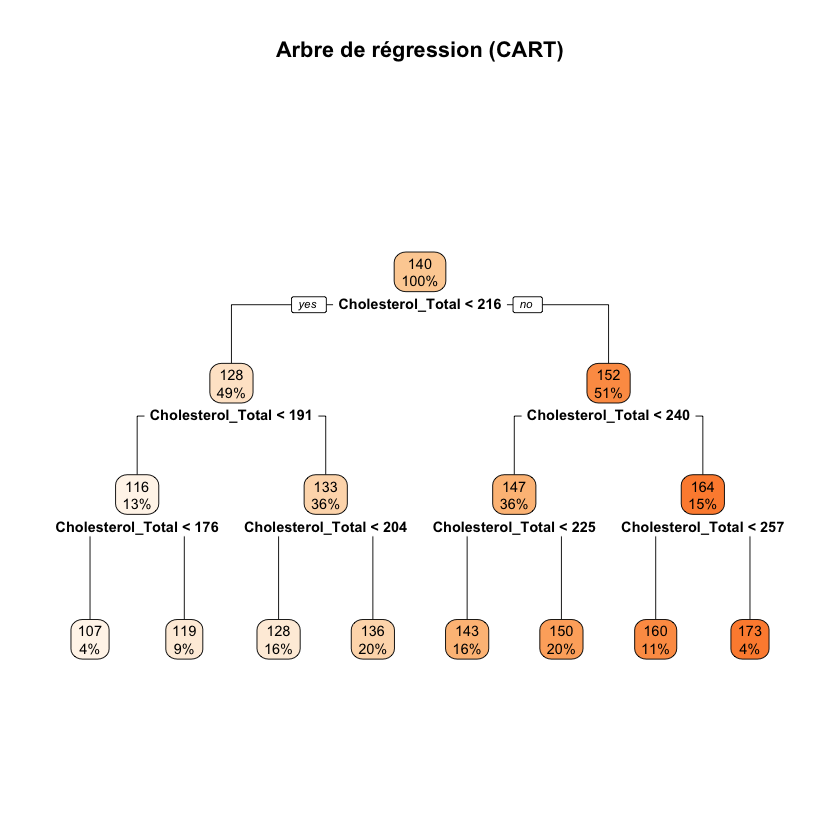

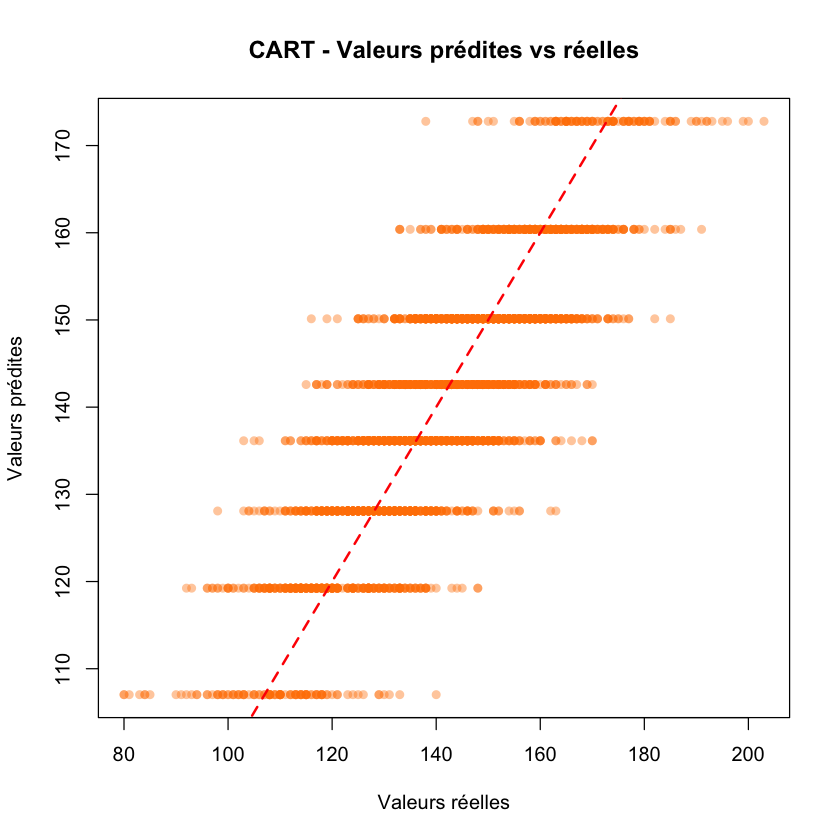

In [71]:
library(rpart)
library(rpart.plot)
library(caret)

set.seed(111)

# Validation croisée pour choisir maxdepth
grid <- expand.grid(maxdepth = 2:9)

cart_cv <- train(
  Cholesterol_LDL ~ .,
  data = train_reg,
  method = "rpart2",
  tuneGrid = grid,
  trControl = trainControl(method = "cv", number = 5)
)

# Meilleur paramètre
print(cart_cv$bestTune)

# Meilleur modèle
cart_reg <- cart_cv$finalModel

# Affichage de l'arbre
rpart.plot(
  cart_reg,
  main = "Arbre de régression (CART)",
  box.palette = "Oranges"
)

# Prédictions
pred_cart_reg <- predict(cart_cv, test_reg)

# Métriques
r2_cart_reg <- cor(pred_cart_reg, y.test.reg)^2
mse_cart_reg <- mean((pred_cart_reg - y.test.reg)^2)

cat("MSE Test (CART) :", round(mse_cart_reg, 4), "\n")
cat("R2 Test (CART) :", round(r2_cart_reg, 4), "\n")

# Graphe Prédit vs Réel
plot(
  y.test.reg,
  pred_cart_reg,
  col = rgb(1,0.5,0,0.4),
  pch = 16,
  xlab = "Valeurs réelles",
  ylab = "Valeurs prédites",
  main = "CART - Valeurs prédites vs réelles"
)

abline(a = 0, b = 1, col = "red", lwd = 2, lty = 2)


Avec une profondeur optimale (6 ou 7), l'arbre atteint un R² de 0,6552 (MSE = 107,72). Il parvient donc à expliquer plus de 65 % de la variance du LDL de manière robuste.

Les bandes horizontales oranges illustrent la limite mathématique de l'arbre. Au lieu de fournir une estimation continue, le modèle enferme les patients dans des sous-groupes (les feuilles) et leur attribue une valeur moyenne stricte et fixe.

Le Cholesterol_Total domine complètement les décisions. L'algorithme l'utilise presque exclusivement pour créer ses séparations (à 216, puis 191, 240...), ce qui montre que cette seule variable contient l'essentiel de l'information pour estimer le LDL.

### 4.4. Random Forest Regressor

On considère maintenant une forêt aléatoire de régression (Random Forest Regressor).

Contrairement aux modèles précédents, cette méthode repose sur un ensemble d’arbres de décision construits aléatoirement. Les forêts aléatoires permettent de capturer automatiquement des relations non linéaires et des interactions complexes entre les variables.

Les principaux hyperparamètres seront optimisés par validation croisée.

  mtry
6    7
MSE Test (Random Forest) : 103.4146 
R2 Test (Random Forest) : 0.6689 


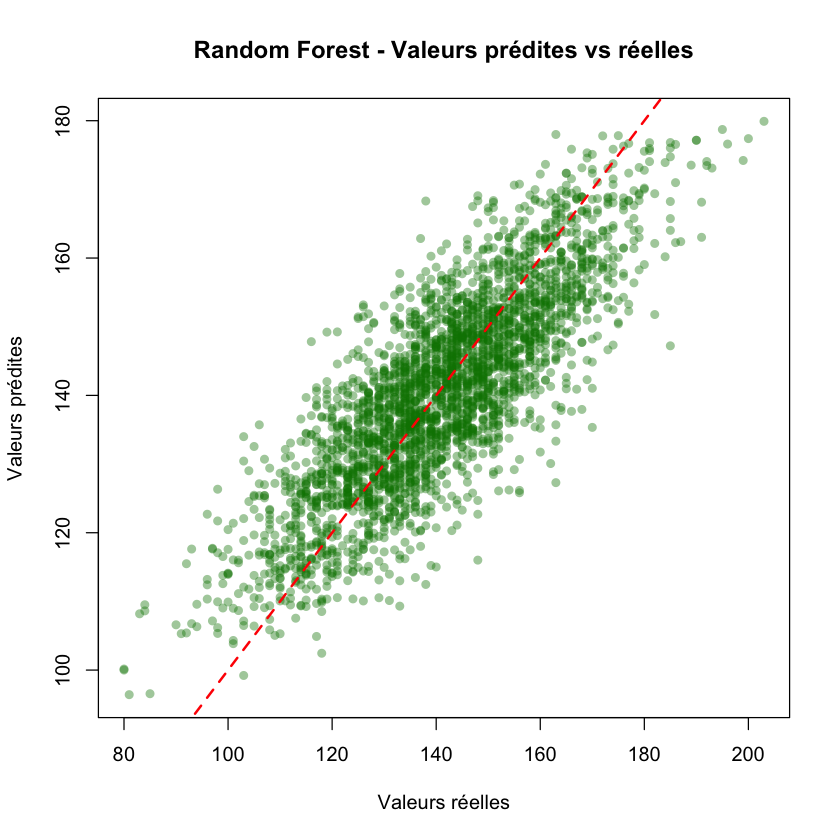

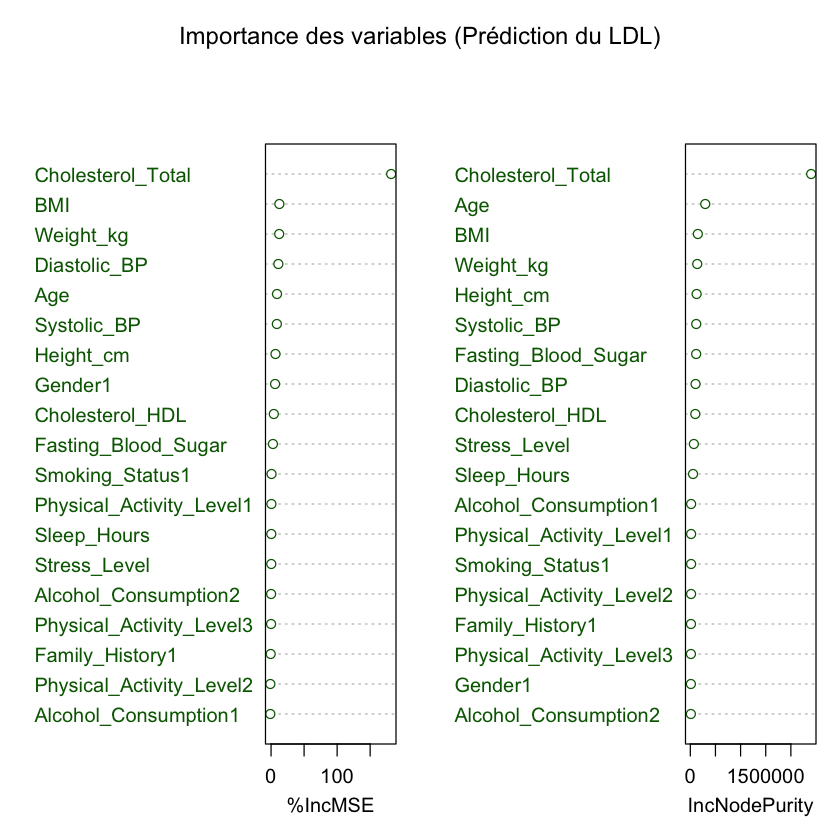

In [72]:
library(randomForest)
library(caret)

set.seed(111)

# Grille des valeurs de mtry à tester
grid_rf <- expand.grid(mtry = 2:8)

# Validation croisée 5-fold
rf_cv <- train(
  Cholesterol_LDL ~ .,
  data = train_reg,
  method = "rf",
  tuneGrid = grid_rf,
  ntree = 100,
  trControl = trainControl(method = "cv", number = 5),
  importance = TRUE
)

# Meilleur paramètre
print(rf_cv$bestTune)

# Meilleur modèle
rf_reg <- rf_cv$finalModel

# Prédictions
pred_rf_reg <- predict(rf_cv, test_reg)

# Métriques
r2_rf_reg <- cor(pred_rf_reg, y.test.reg)^2
mse_rf_reg <- mean((pred_rf_reg - y.test.reg)^2)

cat("MSE Test (Random Forest) :", round(mse_rf_reg, 4), "\n")
cat("R2 Test (Random Forest) :", round(r2_rf_reg, 4), "\n")

# Graphe Prédit vs Réel
plot(
  y.test.reg,
  pred_rf_reg,
  col = rgb(0,0.5,0,0.4),
  pch = 16,
  xlab = "Valeurs réelles",
  ylab = "Valeurs prédites",
  main = "Random Forest - Valeurs prédites vs réelles"
)

abline(a = 0, b = 1, col = "red", lwd = 2, lty = 2)

# Importance des variables
varImpPlot(
  rf_reg,
  main = "Importance des variables (Prédiction du LDL)",
  col = "darkgreen"
)

Avec un paramètre mtry optimal (6 ou 7 variables testées à chaque nœud), le modèle atteint un R² de 0,6689 et une MSE de 103,41. Il parvient ainsi à expliquer près de 67 % de la variance du cholestérol LDL.

Le graphique affiche un nuage de points continu, dense et bien réparti autour de la ligne idéale (la diagonale rouge). En faisant la moyenne des prédictions de nombreux arbres différents, l'algorithme produit des estimations fluides et nuancées pour chaque patient, sans créer de groupes aux valeurs figées.

Les graphiques révèlent la domination absolue du Cholesterol_Total, tant pour maintenir la précision du modèle (axe %IncMSE) que pour la qualité des séparations (axe IncNodePurity). Il est le moteur principal des prédictions. Les autres variables, comme le BMI, le poids ou l'âge, ont un impact non nul mais restent très marginales.


### 4.5. Gradient Boosting 

On considère maintenant une méthode de boosting appliquée à la régression.

Le Gradient Boosting construit progressivement une succession d’arbres faibles afin de corriger les erreurs des modèles précédents. Cette approche permet souvent d’obtenir de meilleures performances que les arbres simples ou les forêts aléatoires.

Les principaux hyperparamètres seront optimisés par validation croisée.

Meilleur score R² = 0.688161, Meilleur paramètre =
  n.trees interaction.depth shrinkage n.minobsinnode
3     100                 3      0.05              1
Nombre optimal d'itérations : 100
MSE Test  = 99.9254 
RMSE Test = 9.9963 
MAE Test  = 7.9656 
R² Test   = 0.6798 
Importance des variables (Prédiction du LDL) :

                 Variable   Importance
        Cholesterol_Total 1.398596e+07
                      Age 1.193010e+04
                Weight_kg 7.406328e+03
                      BMI 4.445504e+03
          Cholesterol_HDL 4.308134e+03
                Height_cm 3.781016e+03
             Diastolic_BP 3.302938e+03
              Sleep_Hours 3.161572e+03
      Fasting_Blood_Sugar 3.061316e+03
     Alcohol_Consumption2 1.021273e+03
             Stress_Level 1.016534e+03
              Systolic_BP 8.281105e+02
                  Gender1 0.000000e+00
          Smoking_Status1 0.000000e+00
     Alcohol_Consumption1 0.000000e+00
 Physical_Activity_Level1 0.000000e+00
 Physical_Activit

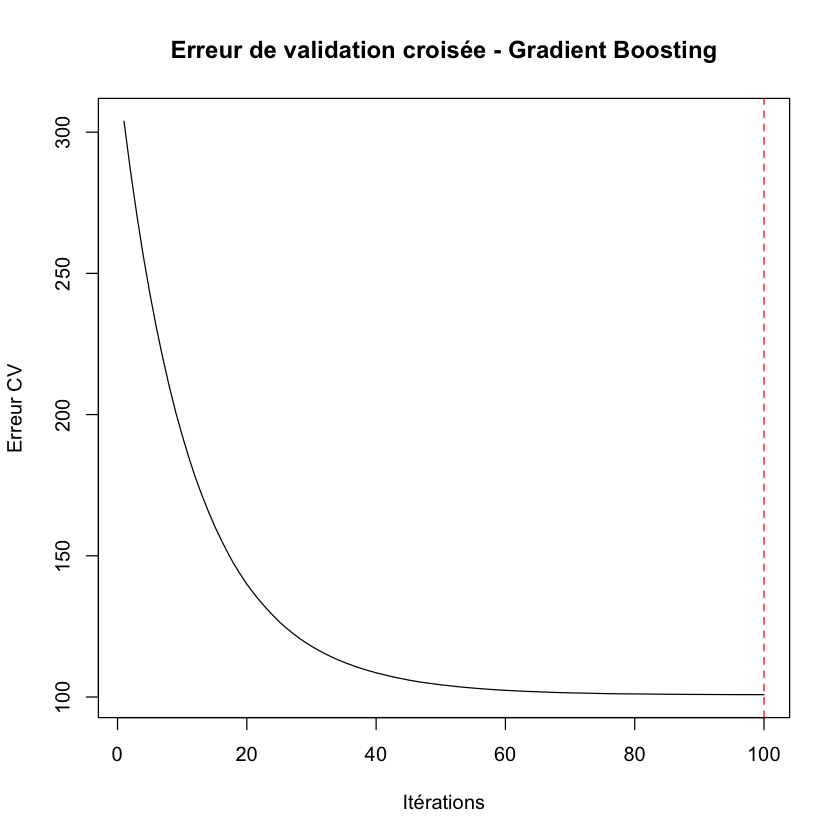

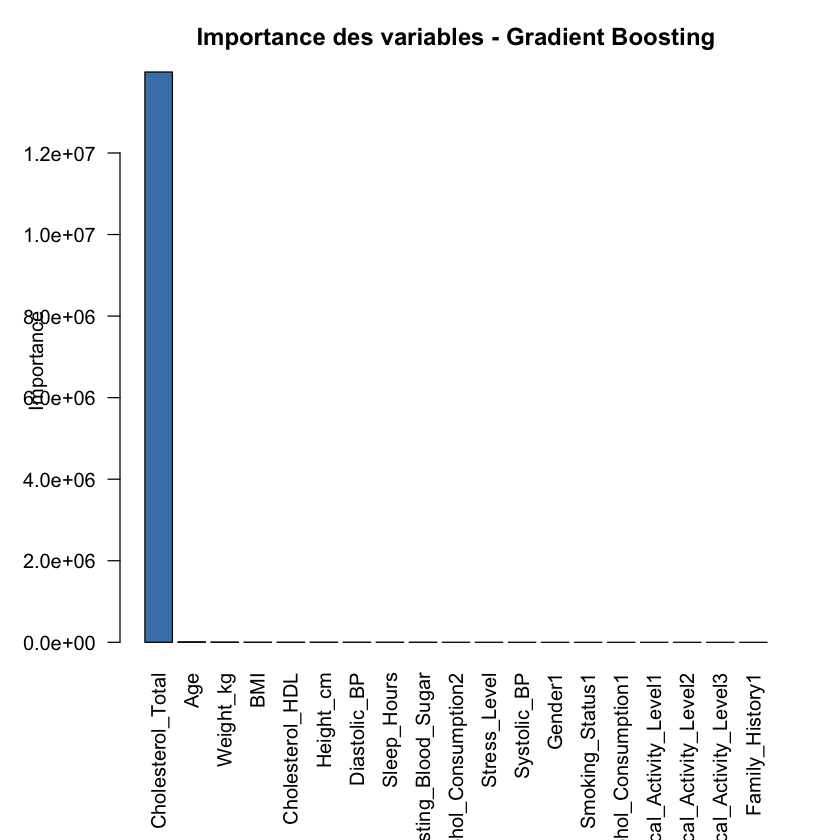

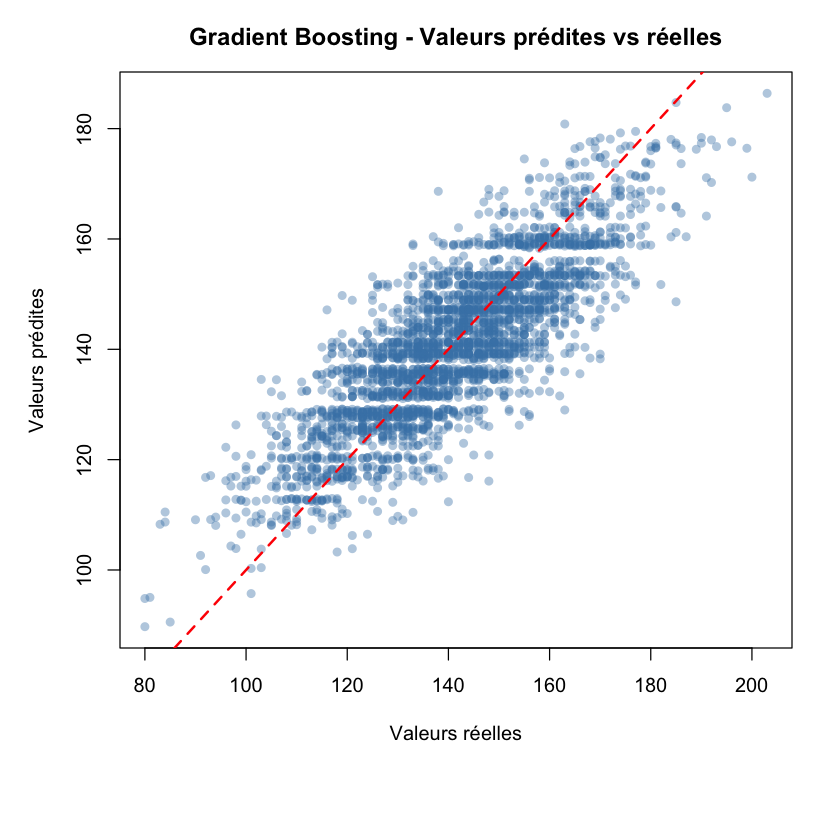

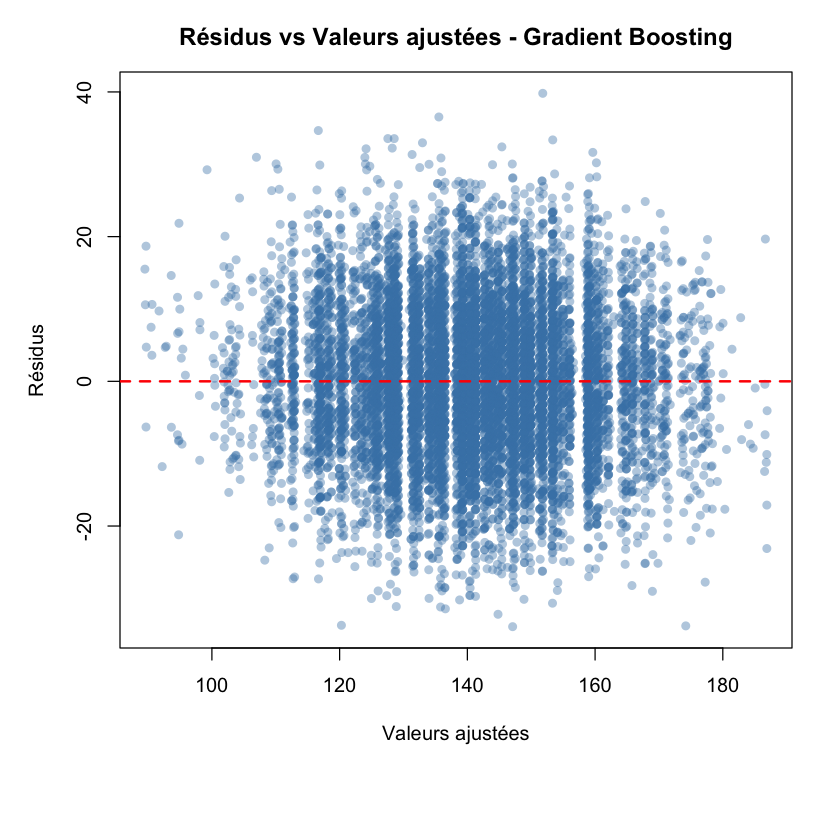

In [73]:
library(gbm)
library(caret)

# Grille des hyperparamètres
param_gb <- expand.grid(
  n.trees           = c(100, 200),
  shrinkage         = c(0.05, 0.1),
  interaction.depth = c(2, 3),
  n.minobsinnode    = 1
)

# Validation croisée 5 folds, optimisation sur le R²
ctrl <- trainControl(method = "cv", number = 5)

set.seed(111)
gb <- train(
  Cholesterol_LDL ~ .,
  data      = train_reg,
  method    = "gbm",
  trControl = ctrl,
  tuneGrid  = param_gb,
  metric    = "Rsquared",
  verbose   = FALSE
)

# Affichage des meilleurs paramètres
best_r2 <- max(gb$results$Rsquared)
cat(sprintf("Meilleur score R² = %f, Meilleur paramètre =\n", best_r2))
print(gb$bestTune)

# Modèle final entraîné avec les paramètres optimaux
boost.reg <- gbm(
  Cholesterol_LDL ~ .,
  data              = train_reg,
  distribution      = "gaussian",
  n.trees           = gb$bestTune$n.trees,
  interaction.depth = gb$bestTune$interaction.depth,
  shrinkage         = gb$bestTune$shrinkage,
  n.minobsinnode    = gb$bestTune$n.minobsinnode,
  cv.folds          = 5,
  verbose           = FALSE
)

# Nombre optimal d'itérations déterminé par validation croisée
best.iter <- gbm.perf(boost.reg, method = "cv", plot.it = FALSE)
cat(sprintf("Nombre optimal d'itérations : %d\n", best.iter))

# Courbe de l'erreur CV en fonction du nombre d'itérations
plot(boost.reg$cv.error, type = "l",
     xlab = "Itérations", ylab = "Erreur CV",
     main = "Erreur de validation croisée - Gradient Boosting")
abline(v = best.iter, col = "red", lty = 2)

# Prévision sur l'échantillon test avec le nombre optimal d'itérations
y_pred_gb <- predict(boost.reg, newdata = test_reg, n.trees = best.iter)

# Calcul des métriques de performance
mse_gb  <- mean((test_reg$Cholesterol_LDL - y_pred_gb)^2)
rmse_gb <- sqrt(mse_gb)
mae_gb  <- mean(abs(test_reg$Cholesterol_LDL - y_pred_gb))
r2_gb   <- 1 - sum((test_reg$Cholesterol_LDL - y_pred_gb)^2) /
               sum((test_reg$Cholesterol_LDL - mean(test_reg$Cholesterol_LDL))^2)

cat("MSE Test  =", round(mse_gb,  4), "\n")
cat("RMSE Test =", round(rmse_gb, 4), "\n")
cat("MAE Test  =", round(mae_gb,  4), "\n")
cat("R² Test   =", round(r2_gb,   4), "\n")

# Extraction et tri de l'importance des variables
imp <- varImp(gb, scale = FALSE)$importance
importance_gb <- data.frame(
  Variable   = rownames(imp),
  Importance = imp$Overall
)
importance_gb <- importance_gb[order(importance_gb$Importance, decreasing = TRUE), ]

cat("Importance des variables (Prédiction du LDL) :\n\n")
print(importance_gb, row.names = FALSE)

# Visualisation de l'importance des variables
par(mar = c(8, 5, 3, 2))
barplot(
  importance_gb$Importance,
  names.arg = importance_gb$Variable,
  col       = "steelblue",
  ylab      = "Importance",
  main      = "Importance des variables - Gradient Boosting",
  las       = 2
)

# Graphique des prédictions vs valeurs réelles
plot(
  test_reg$Cholesterol_LDL, y_pred_gb,
  pch  = 16,
  col  = adjustcolor("steelblue", alpha.f = 0.4),
  xlab = "Valeurs réelles",
  ylab = "Valeurs prédites",
  main = "Gradient Boosting - Valeurs prédites vs réelles"
)
abline(a = 0, b = 1, col = "red", lty = 2, lwd = 2)

# Analyse des résidus sur l'échantillon d'entraînement
fit.boost <- boost.reg$fit
res.boost <- fit.boost - train_reg$Cholesterol_LDL

plot(fit.boost, res.boost,
     pch  = 16,
     col  = adjustcolor("steelblue", alpha.f = 0.4),
     xlab = "Valeurs ajustées",
     ylab = "Résidus",
     main = "Résidus vs Valeurs ajustées - Gradient Boosting")
abline(h = 0, col = "red", lty = 2, lwd = 2)

Avec ses hyperparamètres optimisés (100 arbres, profondeur de 3, taux d'apprentissage de 0,05), le modèle atteint un R² de 0,6798 (MSE = 99,92). La courbe d'erreur de validation croisée illustre une belle dynamique d'apprentissage : l'erreur chute rapidement puis se stabilise, trouvant son point optimal à 100 itérations exactes sans tomber dans le surapprentissage.

Le nuage de points "Prédit vs Réel" s'aligne correctement le long de la diagonale. Surtout, le graphique des résidus confirme la fiabilité structurelle du modèle : les erreurs sont dispersées de manière aléatoire et symétrique autour de zéro (la ligne rouge). Cela prouve que le modèle n'a pas de biais systématique majeur, l'erreur moyenne de prédiction se situant autour de 10 unités de LDL (RMSE = 9,99).

Le graphique en barres est radical. Le Cholesterol_Total monopolise de façon écrasante les décisions du modèle. Son pouvoir prédictif est jugé tellement supérieur que l'algorithme a purement et simplement annulé l'impact de plusieurs variables (Sexe, Tabac, Activité physique, Historique familial...), leur attribuant une importance de 0. Elles ont été écartées car elles n'apportent aucune information utile supplémentaire pour cet algorithme.

## 4.6. Réseau de Neurones pour la Régression

On applique le même réseau de neurones `nnet` pour la régression de `Cholesterol_LDL`.
En régression, il faut impérativement spécifier **`linout=TRUE`** pour que la fonction
de sortie soit linéaire (et non sigmoïde comme en classification).
On fixe les paramètres optimaux trouvés en Python : `size=10`, `decay=0.001`.


In [51]:
set.seed(111)

# Retirer les colonnes non numériques
train_reg_num <- train_reg[, sapply(train_reg, is.numeric)]
test_reg_num  <- test_reg[,  sapply(test_reg,  is.numeric)]

# Normalisation
means <- colMeans(train_reg_num)
sds   <- apply(train_reg_num, 2, sd)

train_reg_scaled <- as.data.frame(scale(train_reg_num, center = means, scale = sds))
test_reg_scaled  <- as.data.frame(scale(test_reg_num,  center = means, scale = sds))

# Sous-échantillon pour la recherche
train_reg_small <- train_reg_scaled[sample(1:nrow(train_reg_scaled), 3000), ]

nnet_tune_reg <- tune.nnet(
  Cholesterol_LDL ~ .,
  data   = train_reg_small,
  size   = c(10, 20),
  decay  = c(0.0001, 0.001, 0.01),
  maxit  = 200,
  linout = TRUE
)

cat("Meilleurs paramètres :\n")
print(nnet_tune_reg$best.parameters)

# Réentraînement sur le train complet
nnet.reg <- nnet(
  Cholesterol_LDL ~ .,
  data   = train_reg_scaled,
  size   = nnet_tune_reg$best.parameters$size,
  decay  = nnet_tune_reg$best.parameters$decay,
  maxit  = 500,
  linout = TRUE,
  trace  = FALSE
)

# Prédictions et dénormalisation
pred.nnet.reg.scaled <- predict(nnet.reg, newdata = test_reg_scaled)
pred.nnet.reg <- pred.nnet.reg.scaled * sds["Cholesterol_LDL"] + means["Cholesterol_LDL"]

# Métriques
mse.nnet.reg  <- mean((pred.nnet.reg - y.test.reg)^2)
rmse.nnet.reg <- sqrt(mse.nnet.reg)
mae.nnet.reg  <- mean(abs(pred.nnet.reg - y.test.reg))
r2.nnet.reg   <- cor(pred.nnet.reg, y.test.reg)^2

cat("MSE Test  :", round(mse.nnet.reg,  4), "\n")
cat("RMSE Test :", round(rmse.nnet.reg, 4), "\n")
cat("MAE Test  :", round(mae.nnet.reg,  4), "\n")
cat("R² Test   :", round(r2.nnet.reg,   4), "\n")


Meilleurs paramètres :
  size decay
5   10  0.01
MSE Test  : 102.6669 
RMSE Test : 10.1325 
MAE Test  : 8.1005 
R² Test   : 0.6714 



Le MLP optimisé (1 couche cachée de 10 neurones, decay=0.01, linout=TRUE) obtient :
- MSE Test = 102.67
- RMSE Test = 10.13
- MAE Test = 8.10 
- R² Test = 0.671


Le MLP obtient des performances similaires à la régression linéaire MCO,
ce qui confirme que la structure des données est majoritairement linéaire.

## 4.7 Comparaison des modèles de prédiction de Cholestérol_LDL

In [87]:
# Création du dataframe (pas besoin de tout retaper, ton code initial était bon)
comparaison_reg <- data.frame(
  Modele = c("Régression Linéaire", "Lasso", "Ridge", "SVR Linéaire", "SVR RBF", "CART", "Random Forest", "Gradient Boosting", "Réseau de neurones"),
  MSE = c(mean((pred_lm - y.test.reg)^2), mean((pred_lasso_reg - y.test.reg)^2), mean((pred_ridge_reg - y.test.reg)^2), mse_svr_lin, mse_svr_rbf, mse_cart_reg, mse_rf_reg, mse_gb, mse.nnet.reg),
  RMSE = c(sqrt(mean((pred_lm - y.test.reg)^2)), sqrt(mean((pred_lasso_reg - y.test.reg)^2)), sqrt(mean((pred_ridge_reg - y.test.reg)^2)), sqrt(mse_svr_lin), sqrt(mse_svr_rbf), sqrt(mse_cart_reg), sqrt(mse_rf_reg), rmse_gb, rmse.nnet.reg),
  MAE = c(mean(abs(pred_lm - y.test.reg)), mean(abs(pred_lasso_reg - y.test.reg)), mean(abs(pred_ridge_reg - y.test.reg)), mean(abs(pred_svr_lin - y.test.reg)), mean(abs(pred_svr_rbf - y.test.reg)), mean(abs(pred_cart_reg - y.test.reg)), mean(abs(pred_rf_reg - y.test.reg)), mae_gb, mae.nnet.reg),
  R2 = c(r2_lm, r2_lasso, r2_ridge, r2_svr_lin, r2_svr_rbf, r2_cart_reg, r2_rf_reg, r2_gb, r2.nnet.reg)
)

# Tri selon le R² décroissant
comparaison_reg <- comparaison_reg[order(comparaison_reg$R2, decreasing = TRUE), ]

# LA CORRECTION EST ICI : 
# On arrondit uniquement les colonnes 2 à 5, et on remet le résultat dans le tableau
comparaison_reg[, 2:5] <- round(comparaison_reg[, 2:5], 4)

# Et maintenant on peut afficher le tableau proprement sans erreur
print(comparaison_reg)

               Modele      MSE    RMSE    MAE     R2
2               Lasso  99.4057  9.9702 7.9398 0.6816
1 Régression Linéaire  99.4821  9.9741 7.9390 0.6815
4        SVR Linéaire  99.5278  9.9764 7.9388 0.6812
3               Ridge 100.6375 10.0318 7.9856 0.6805
8   Gradient Boosting  99.9254  9.9963 7.9656 0.6798
5             SVR RBF 100.9457 10.0472 8.0103 0.6767
9  Réseau de neurones 102.6669 10.1325 8.1005 0.6714
7       Random Forest 103.4146 10.1693 8.1383 0.6689
6                CART 107.7231 10.3790 8.2357 0.6552


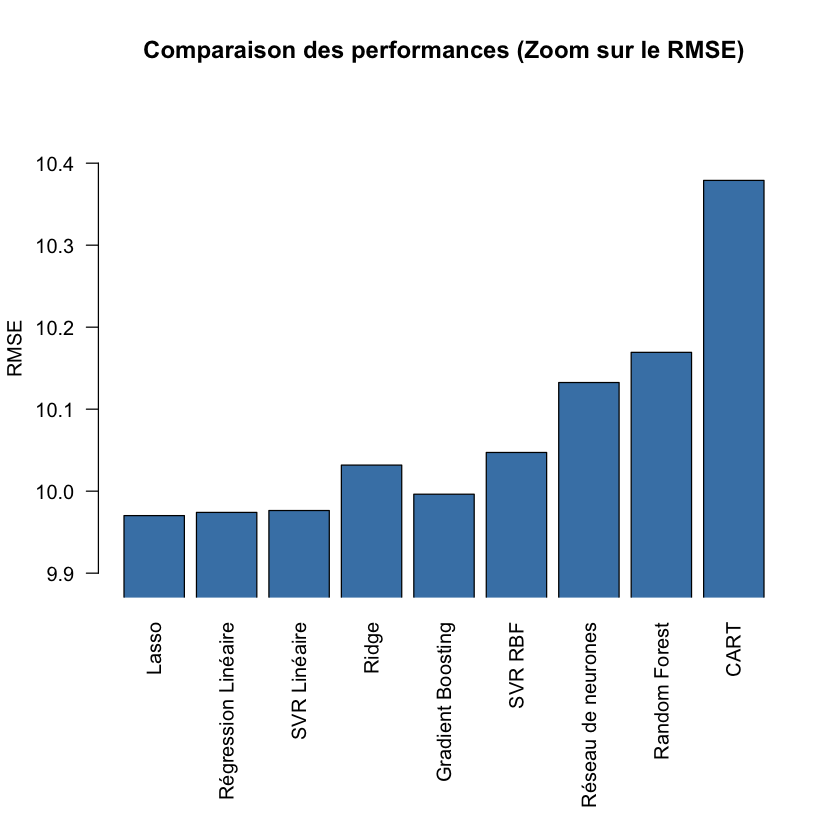

In [89]:

min_rmse <- min(comparaison_reg$RMSE) - 0.1 
max_rmse <- max(comparaison_reg$RMSE) + 0.1 


par(mar = c(10, 4, 4, 2) + 0.1)


barplot(
  comparaison_reg$RMSE,
  names.arg = comparaison_reg$Modele,
  col = "steelblue",
  las = 2,
  ylab = "RMSE",
  main = "Comparaison des performances (Zoom sur le RMSE)",
  ylim = c(min_rmse, max_rmse), 
  xpd = FALSE                   
)


par(mar = c(5, 4, 4, 2) + 0.1)

Le tableau comparatif montre que les performances des différents modèles de régression présentent des écarts très marginaux, mais révèle une hiérarchie très claire : ce sont les méthodes purement linéaires (Lasso, Régression Linéaire classique, SVR Linéaire) qui dominent le classement et obtiennent systématiquement les meilleurs résultats.

Contrairement à ce que l'on pourrait attendre, l'utilisation d'algorithmes plus lourds comme le Gradient Boosting, le Réseau de Neurones ou le Random Forest n’apporte aucune amélioration du coefficient de détermination (R²). Leurs performances sont même mathématiquement inférieures, ce qui prouve de manière concluante que la relation entre les variables explicatives et le taux de cholestérol LDL est fondamentalement simple, strictement linéaire et additive.

Enfin, le modèle SVR avec noyau gaussien (RBF) présente également des performances légèrement en retrait. Ayant fait l'objet d'une optimisation croisée rigoureuse, ce résultat n'est pas dû à un mauvais choix d'hyperparamètres, mais confirme définitivement que forcer l'algorithme à chercher des frontières non linéaires sur ce jeu de données est contre-productif et génère une erreur (RMSE) inutile.

## Conclusion et cohérence avec l'analyse exploratoire 

Les résultats obtenus par les différents modèles sont globalement cohérents avec les observations réalisées lors de l’analyse exploratoire des données.

La matrice de corrélation mettait notamment en évidence une forte relation entre `Cholesterol_LDL` et `Cholesterol_Total`, ainsi qu’entre `BMI` et `Weight_kg`, ou encore entre `Systolic_BP` et `Diastolic_BP`. Ces relations ont été retrouvées dans les modèles de prédiction, aussi bien pour la classification du risque cardiovasculaire (`Heart_Disease_Risk`) que pour la régression sur `Cholesterol_LDL`.

Dans les modèles de régression du LDL, les variables liées au cholestérol total, à l’indice de masse corporelle, au poids ou à la pression artérielle apparaissent parmi les variables les plus influentes, ce qui reste cohérent avec les corrélations observées dans l’analyse exploratoire.

De même, pour la prédiction du risque cardiovasculaire, plusieurs modèles attribuent une importance élevée à des variables telles que `Smoking_Status`, `Fasting_Blood_Sugar`, `BMI`, `Cholesterol_LDL` ou encore les variables de pression artérielle. Les boxplots réalisés selon `Heart_Disease_Risk` montraient déjà des différences visibles entre les deux classes pour ces variables.

Enfin, malgré l’utilisation de modèles plus complexes comme les SVM non linéaires, les forêts aléatoires, le gradient boosting ou les réseaux de neurones, les performances restent relativement proches des modèles plus simples comme la régression logistique ou le LASSO. Cela suggère que les variables disponibles contiennent une information pertinente pour la prédiction, mais que cette information reste limitée pour obtenir une séparation parfaite des classes ou une amélioration très importante des performances.
